# Final Pipeline Tutorial: Evidence Selection And Classification

This tutorial keeps the meeting-notebook story arc, but it now matches the strict Round18 chain and the recovery experiments.

```text
raw JSON
-> single-source sparse gates
-> two multi-gate sparse routes:
   score fusion and candidate union
-> cost-aware top-500 gate decision
-> hand-feature compression
-> full-pool semantic reranking for classifier-context candidates
-> separate top-3 evidence ranking for the submitted evidence list
-> strict context classifier
```

The main correction is that the old mixed-context classifier is excluded from the main result: its train and dev contexts came from different sources. The promoted classifier line uses the same candidate-family context for train and dev, with no hidden fallback.


In [1]:
# 1. Imports and plotting defaults
import csv
import json
import math
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, PercentFormatter

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 180,
    'font.size': 10.5,
    'axes.titlesize': 12,
    'axes.labelsize': 10.5,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
FIG_DIR = ROOT / 'group_meetings/second_meeting /figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = ['SUPPORTS', 'REFUTES', 'NOT_ENOUGH_INFO', 'DISPUTED']
LABEL_DISPLAY = {'SUPPORTS': 'SUPPORTS', 'REFUTES': 'REFUTES', 'NOT_ENOUGH_INFO': 'NEI', 'DISPUTED': 'DISPUTED'}
TOP_N = [1, 3, 5, 10, 20, 32, 50, 64, 100, 200, 300, 500, 1000, 2000]
PERCENT = PercentFormatter(1.0)

COLORS = {
    'blue': '#4C78A8',
    'orange': '#F58518',
    'green': '#54A24B',
    'red': '#C44E52',
    'purple': '#7E62A3',
    'gray': '#8C9AA9',
    'teal': '#2F9C95',
    'gold': '#B79A20',
    'pink': '#D37295',
    'brown': '#9D755D',
    'cyan': '#72B7B2',
    'black': '#2D3748',
}

METHOD_COLORS = {
    'BM25 word gate': COLORS['gray'],
    'Character n-gram gate': COLORS['blue'],
    'Structured cue gate': COLORS['green'],
    'Query expansion gate': COLORS['gold'],
    'Fixed score-fusion gate': COLORS['purple'],
    'Hand-feature reranker': COLORS['pink'],
    'Word+character union pool': COLORS['teal'],
    'Word+character candidate gate': COLORS['teal'],
    'Four-gate union pool': COLORS['orange'],
    'Union pool + cheap ranker': COLORS['red'],
    'Sparse baseline': COLORS['purple'],
    'Top-64 semantic reranker': COLORS['brown'],
    'CE after hand-feature top64': COLORS['brown'],
    'CE after union+cheap top64': COLORS['red'],
    'Hand-feature + full-pool CE': COLORS['cyan'],
    'Same-family CE-only selector': COLORS['cyan'],
    'MiniLM cross-encoder selector': COLORS['cyan'],
    'Embedding inner-product selector': COLORS['green'],
    'Hand-feature selector on same candidates': COLORS['pink'],
    'Embedding + shallow feature ranker': COLORS['gold'],
    'CE plus factual shallow features': COLORS['green'],
    'Top-3 submission blend': COLORS['black'],
    'Train-selected CE+embedding top-3 fusion': COLORS['black'],
    'CE plus original-rank prior': COLORS['orange'],
    'Diversity control diagnostic': COLORS['gray'],
    'Sparse + semantic fusion': COLORS['cyan'],
    'Evidence-Aware Logistic Classifier': COLORS['blue'],
    'Transformer tokenizer classifier': COLORS['orange'],
    'MiniLM embedding classifier': COLORS['green'],
    'Late-fusion diagnostic': COLORS['gray'],
}

LABEL_COLORS = {
    'SUPPORTS': COLORS['blue'],
    'REFUTES': COLORS['red'],
    'NOT_ENOUGH_INFO': COLORS['green'],
    'DISPUTED': COLORS['purple'],
}

def method_color(name):
    return METHOD_COLORS.get(name, COLORS['gray'])


# 2. Load Data And Helpers

All curves below are recomputed from candidate JSON files, not copied from old slides. Bar charts are used only for categorical comparisons; R-n curves are used when the x-axis is a real operating parameter.


In [2]:
def load_json(path):
    path = ROOT / path if not isinstance(path, Path) else path
    with path.open('r', encoding='utf-8') as f:
        return json.load(f)

def load_csv(path):
    path = ROOT / path if not isinstance(path, Path) else path
    with path.open('r', encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))

def ranked_ids(path):
    payload = load_json(path)
    out = {}
    for claim_id, rows in payload.items():
        normalized = []
        for idx, row in enumerate(rows):
            if not isinstance(row, dict) or 'evidence_id' not in row:
                continue
            rank = row.get('rank', idx + 1)
            try:
                rank = int(rank)
            except Exception:
                rank = idx + 1
            normalized.append((rank, idx, str(row['evidence_id'])))
        normalized.sort(key=lambda item: (item[0], item[1], item[2]))
        seen = set()
        ids = []
        for _, _, evidence_id in normalized:
            if evidence_id in seen:
                continue
            seen.add(evidence_id)
            ids.append(evidence_id)
        out[claim_id] = ids
    return out

def recall_at(claims, ranked, k):
    macro = []
    f_scores = []
    tp = 0
    total_gold = 0
    hit = 0
    for claim_id, claim in claims.items():
        gold = set(claim.get('evidences', []))
        if not gold:
            continue
        pred_list = ranked.get(claim_id, [])[:k]
        pred = set(pred_list)
        inter = gold & pred
        recall = len(inter) / len(gold)
        precision = len(inter) / len(pred_list) if pred_list else 0.0
        f_score = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
        macro.append(recall)
        f_scores.append(f_score)
        tp += len(inter)
        total_gold += len(gold)
        hit += bool(inter)
    return {
        'top_n': k,
        'macro_recall': sum(macro) / len(macro) if macro else 0.0,
        'micro_recall': tp / total_gold if total_gold else 0.0,
        'hit_any': hit / len(macro) if macro else 0.0,
        'evidence_f': sum(f_scores) / len(f_scores) if f_scores else 0.0,
    }

def recall_curve(claims, ranked, top_n=TOP_N):
    max_len = max((len(v) for v in ranked.values()), default=0)
    return [recall_at(claims, ranked, k) for k in top_n if k <= max_len]

def value_at(curve, k, key='macro_recall'):
    for row in curve:
        if row['top_n'] == k:
            return row[key]
    return None

def metric_at(row, k, prefix='dev_macro_recall'):
    return row.get(f'{prefix}@{k}')

def finite(values):
    out = []
    for value in values:
        if value is None:
            continue
        try:
            value = float(value)
        except Exception:
            continue
        if math.isfinite(value):
            out.append(value)
    return out

def percent_ylim(ax, values, pad=0.03, floor=0.0, ceiling=1.0):
    vals = finite(values)
    if not vals:
        return
    low = max(floor, min(vals) - pad)
    high = min(ceiling, max(vals) + pad)
    if high - low < 0.08:
        mid = (high + low) / 2
        low = max(floor, mid - 0.04)
        high = min(ceiling, mid + 0.04)
    ax.set_ylim(low, high)

def savefig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight', facecolor='white')
    return path

def manifest_seconds(path):
    data = load_json(path)
    return float(data.get('runtime', {}).get('wall_seconds', 0.0))

def style_rn_axis(ax, ylabel='macro recall'):
    ax.set_xscale('log')
    ax.set_xticks([1, 3, 10, 64, 100, 500, 1000, 2000])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}' if value >= 1 else ''))
    ax.yaxis.set_major_formatter(PERCENT)
    ax.set_xlabel('N candidates kept')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 0.82)

train_claims = load_json('data/train-claims.json')
dev_claims = load_json('data/dev-claims.json')
evidence = load_json('data/evidence.json')


# 3. Dataset And Retrieval Cost

The dataset summary is a categorical comparison, so a bar chart is the clearest representation. The cost chart is also categorical: it compares the full pair space with the bounded candidate stages.


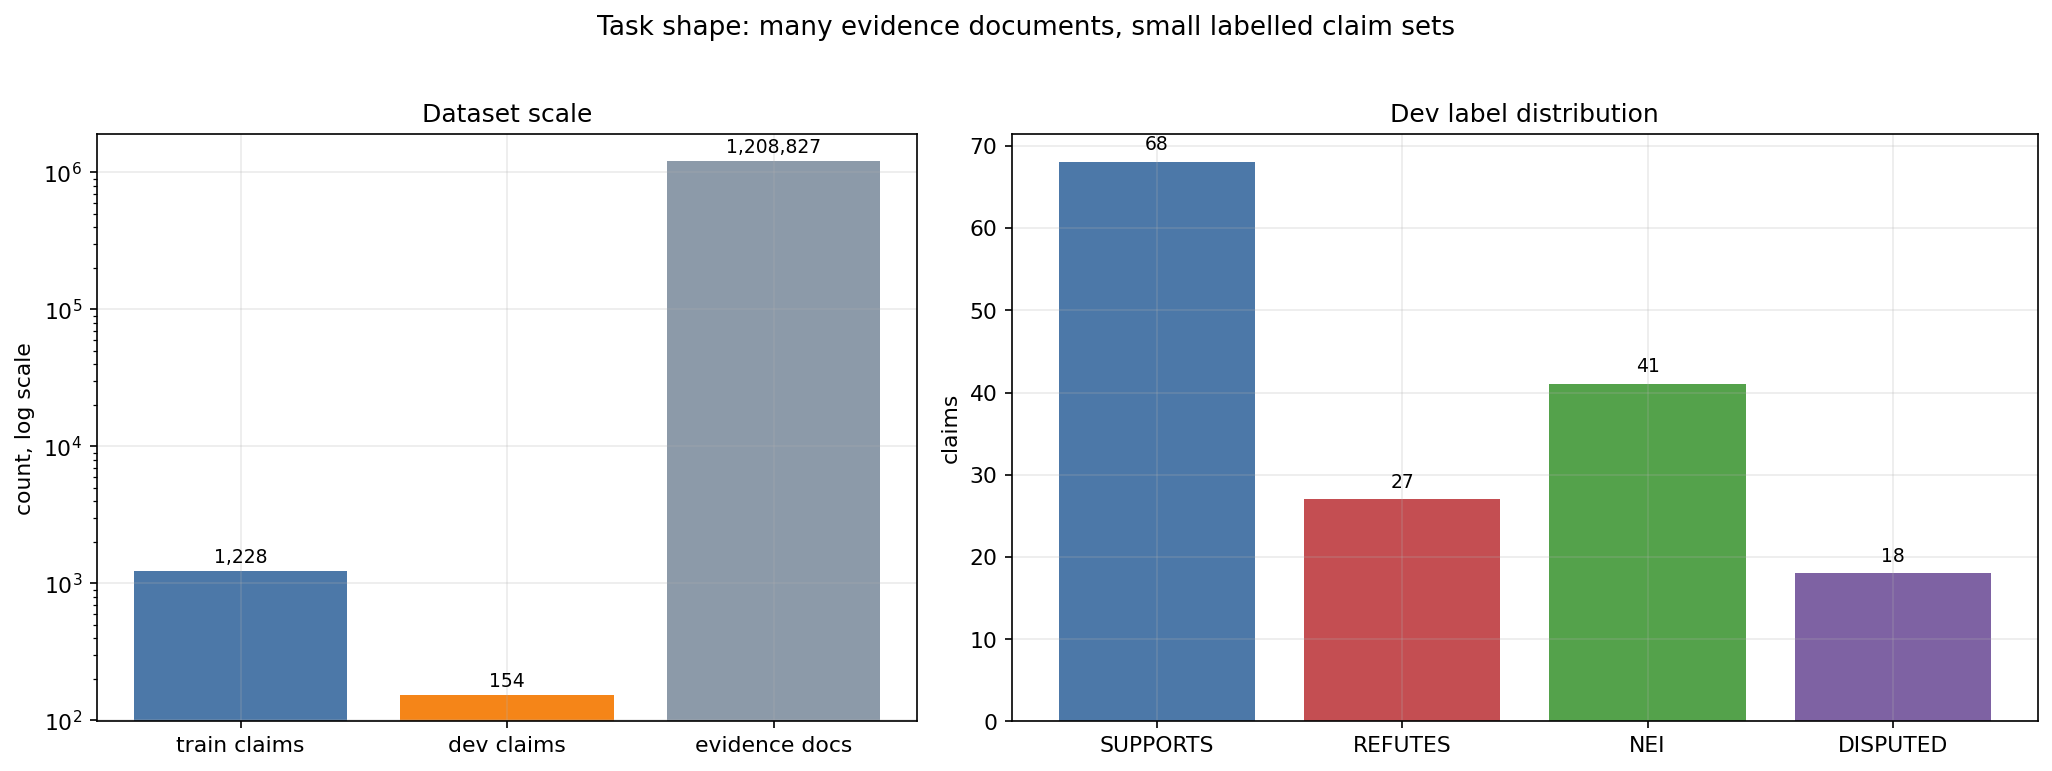

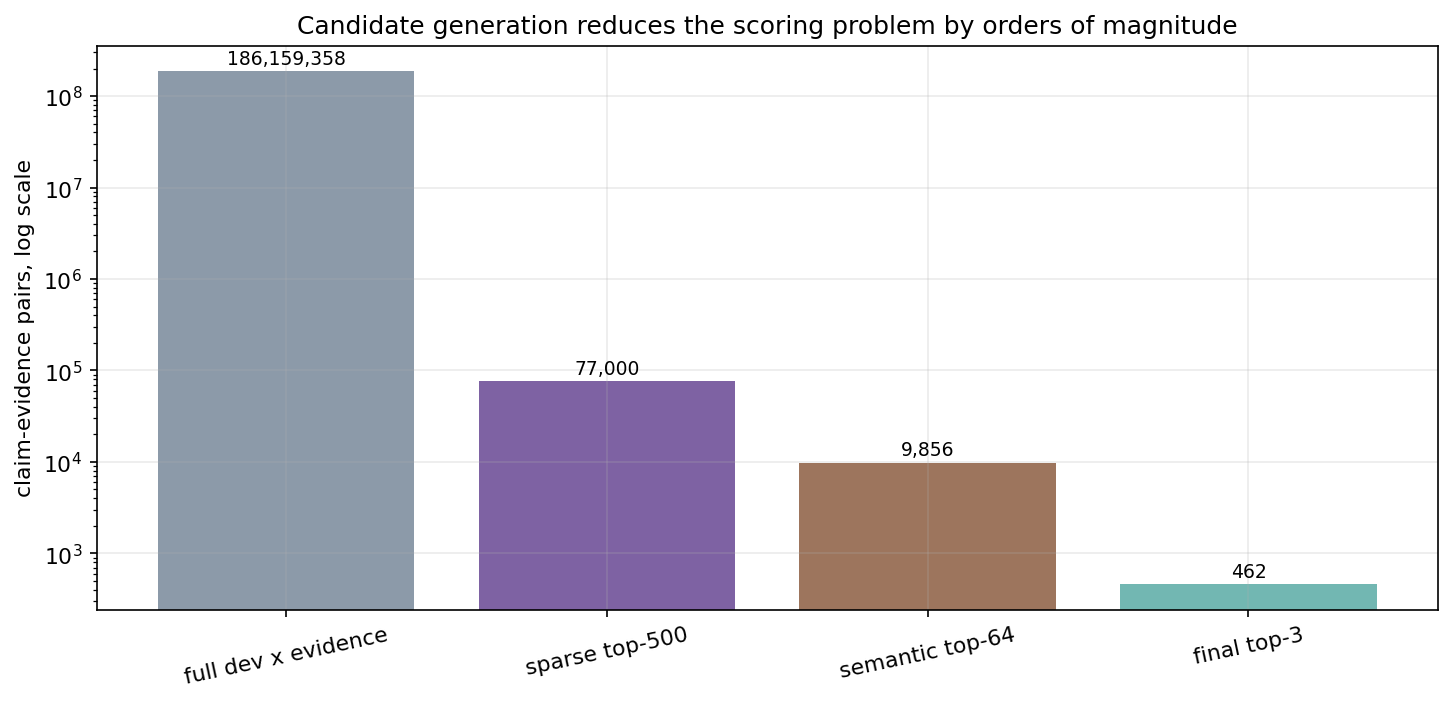

In [3]:
label_counts = Counter(claim['claim_label'] for claim in dev_claims.values())
pair_rows = [
    ('full dev x evidence', len(dev_claims) * len(evidence)),
    ('sparse top-500', len(dev_claims) * 500),
    ('semantic top-64', len(dev_claims) * 64),
    ('final top-3', len(dev_claims) * 3),
]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13.8, 5.0), gridspec_kw={'width_ratios': [1.0, 1.25]})

ax0.bar(['train claims', 'dev claims', 'evidence docs'], [len(train_claims), len(dev_claims), len(evidence)],
        color=[COLORS['blue'], COLORS['orange'], COLORS['gray']])
ax0.set_yscale('log')
ax0.set_title('Dataset scale')
ax0.set_ylabel('count, log scale')
for idx, value in enumerate([len(train_claims), len(dev_claims), len(evidence)]):
    ax0.text(idx, value * 1.08, f'{value:,}', ha='center', va='bottom', fontsize=9)

labels = [LABEL_DISPLAY[x] for x in LABEL_ORDER]
vals = [label_counts.get(x, 0) for x in LABEL_ORDER]
ax1.bar(labels, vals, color=[LABEL_COLORS[x] for x in LABEL_ORDER])
ax1.set_title('Dev label distribution')
ax1.set_ylabel('claims')
for idx, value in enumerate(vals):
    ax1.text(idx, value + 1, str(value), ha='center', va='bottom', fontsize=9)
fig.suptitle('Task shape: many evidence documents, small labelled claim sets', y=1.02)
fig.tight_layout()
savefig('round18_revised_dataset_and_labels.png')
plt.show()

fig, ax = plt.subplots(figsize=(9.8, 4.8))
cost_labels = [name for name, _ in pair_rows]
cost_vals = [value for _, value in pair_rows]
ax.bar(cost_labels, cost_vals, color=[COLORS['gray'], method_color('Fixed score-fusion gate'), method_color('Top-64 semantic reranker'), method_color('Sparse + semantic fusion')])
ax.set_yscale('log')
ax.set_ylabel('claim-evidence pairs, log scale')
ax.set_title('Candidate generation reduces the scoring problem by orders of magnitude')
ax.tick_params(axis='x', rotation=12)
for idx, value in enumerate(cost_vals):
    ax.text(idx, value * 1.08, f'{value:,}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
savefig('round18_revised_candidate_cost_bar.png')
plt.show()


# 4. Sparse Gates And Two Fusion Routes

First we compare the leaf gates by themselves. Then we test two ways to combine multiple gates.

**Score fusion** assigns fixed weights to the leaf gates and produces one ranked list. It keeps the candidate budget controlled from the start.

**Candidate union** first takes candidates from several gates and removes duplicates. This can recover evidence that only one gate sees, but it creates a larger and noisier pool, so it may need a cheap ranking step before the final top-500 cutoff.

R-n curves are appropriate here because the question is functional: how much recall is recovered as we keep more candidates?


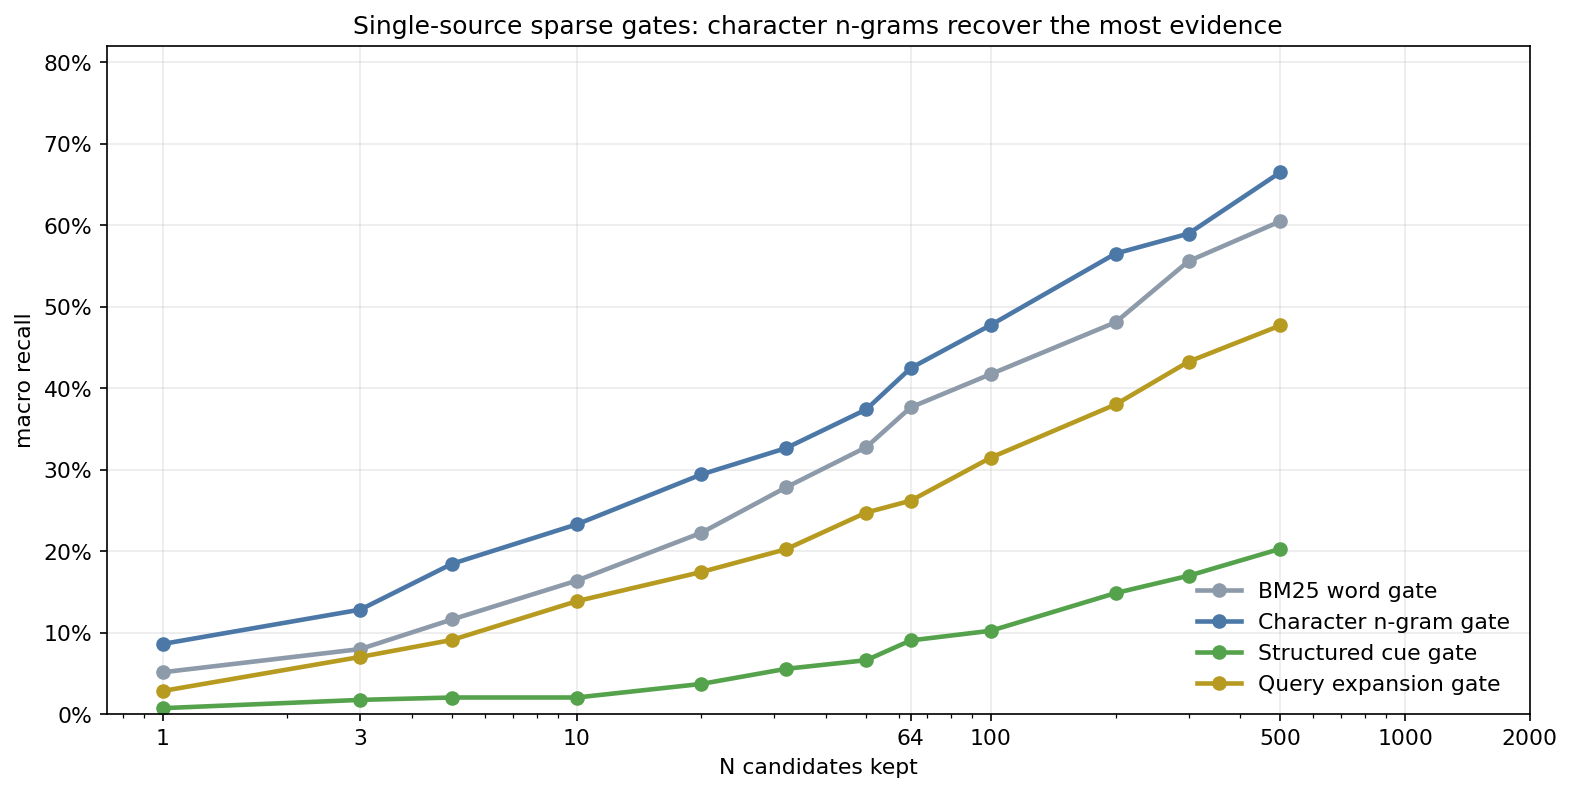

In [4]:
CANDIDATES = {
    'BM25 word gate': 'round18/reports/colab_sklearn_candidate_experiment/bm25_top500.json',
    'Character n-gram gate': 'round18/reports/colab_sklearn_candidate_experiment/char_top500.json',
    'Structured cue gate': 'round18/reports/colab_sklearn_candidate_experiment/structured_top500.json',
    'Query expansion gate': 'round18/reports/colab_sklearn_candidate_experiment/prf_top500.json',
    'Fixed score-fusion gate': 'round18/reports/colab_sklearn_candidate_experiment/fused_char_heavy_top500.json',
    'Hand-feature reranker': 'round18/outputs/o_sparse/o_s8_hand_feature_ranker/dev_full_dev_o_s8_hand_feature_ranker_top500_candidates.json',
    'Word+character union pool': 'round18/outputs/o_sparse/o_s9_union_gate_bm25_char_dev/dev_full_dev_o_s9_union_gate_bm25_char_rrf_top1000_candidates.json',
    'Word+character candidate gate': 'round18/outputs/o_sparse/o_s9_union_gate_bm25_char_dev/dev_full_dev_o_s9_union_gate_bm25_char_rrf_top1000_candidates.json',
    'Four-gate union pool': 'round18/outputs/o_sparse/o_s9_union_gate_four_source_wide_dev/dev_full_dev_o_s9_union_gate_four_source_wide_rrf_top2000_candidates.json',
    'Union pool + cheap ranker': 'round18/outputs/o_sparse/o_s10_wide_hand_feature_bm25_char_round_robin_top1000/dev_full_dev_o_s10_wide_hand_feature_bm25_char_round_robin_top1000_top500_candidates.json',
    'Sparse baseline': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8/dev_full_dev_o_a2c_plain_leaf_rank_s8_strict_sparse_only_top500_candidates.json',
    'Top-64 semantic reranker': 'round18/outputs/o_dense/o_d3b_cross_encoder_s7/dev_full_dev_full_dev_top64_s7_strict_top64_candidates.json',
    'CE after hand-feature top64': 'round18/outputs/o_dense/o_d3x_cross_encoder_s8_diag/dev_full_dev_full_dev_top64_s8_diag_strict_top64_candidates.json',
    'CE after union+cheap top64': 'round18/outputs/o_dense/o_d3x_cross_encoder_s10_diag/dev_full_dev_full_dev_top64_s10_diag_strict_top64_candidates.json',
    'Hand-feature + full-pool CE': 'round18/outputs/o_dense/o_d3x_cross_encoder_s8_top500_diag/dev_full_dev_full_dev_top500_s8_diag_strict_top500_candidates.json',
    'Same-family CE-only selector': 'round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/dev_full_dev_o_d3x_bm25_char_dev_top500_strict_top500_candidates.json',
    'MiniLM cross-encoder selector': 'round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/dev_full_dev_o_d3x_bm25_char_dev_top500_strict_top500_candidates.json',
    'Embedding inner-product selector': 'round18/outputs/o_dense/o_d1x_embedding_bm25_char_dev_top500/dev_full_dev_o_d1x_embedding_bm25_char_dev_top500_strict_top500_candidates.json',
    'CE plus factual shallow features': 'round18/reports/ce_shallow_feature_kfold/ce_shallow_feature_kfold_best_dev_top500_candidates.json',
    'Embedding + shallow feature ranker': 'round18/reports/embedding_shallow_feature_kfold/embedding_shallow_feature_kfold_best_dev_top500_candidates.json',
    'Top-3 submission blend': 'round18/reports/top3_score_fusion_spark/top3_score_fusion_best_dev_full_dev_o_s8_hand_feature_ranker_top500_candidates_min_source_rank_ce0.75_top500_candidates.json',
    'Train-selected CE+embedding top-3 fusion': 'round18/reports/top3_train_kfold_fusion_with_hand/top3_train_kfold_fusion_with_hand_best_dev_top500_candidates.json',
    'CE plus original-rank prior': 'round18/outputs/o_rerank/top3_fusion_grid/dev_top3_fusion_grid_diagnostic_best_candidates.json',
    'Diversity control diagnostic': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8_top3_top10_mmr/dev_full_dev_o_a2c_plain_leaf_rank_s8_top3_top10_mmr_strict_rrf_sparse_ce_mmr_top3_top500_candidates.json',
    'Sparse + semantic fusion': 'round18/outputs/o_aggregate/o_a2c_plain_leaf_rank_s8/dev_full_dev_o_a2c_plain_leaf_rank_s8_strict_rrf_sparse_ce_top500_candidates.json',
}

ranked = {name: ranked_ids(path) for name, path in CANDIDATES.items() if (ROOT / path).exists()}
curves = {name: recall_curve(dev_claims, pool) for name, pool in ranked.items()}

fig, ax = plt.subplots(figsize=(10.6, 5.4))
for name in ['BM25 word gate', 'Character n-gram gate', 'Structured cue gate', 'Query expansion gate']:
    curve = curves[name]
    ax.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.2, label=name, color=method_color(name))
style_rn_axis(ax)
ax.set_title('Single-source sparse gates: character n-grams recover the most evidence')
ax.legend(loc='lower right')
fig.tight_layout()
savefig('round18_revised_single_sparse_rn.png')
plt.show()


## 4.1 Score-Based Fusion

Score fusion combines the leaf-gate ranks with fixed source weights. The weights are a categorical configuration, so they are shown as a bar chart. The retrieval effect is shown as an R-n curve. The deployed candidate gate uses a char-heavy fixed RRF weighting selected by the Colab-feasible sparse-matrix experiment.


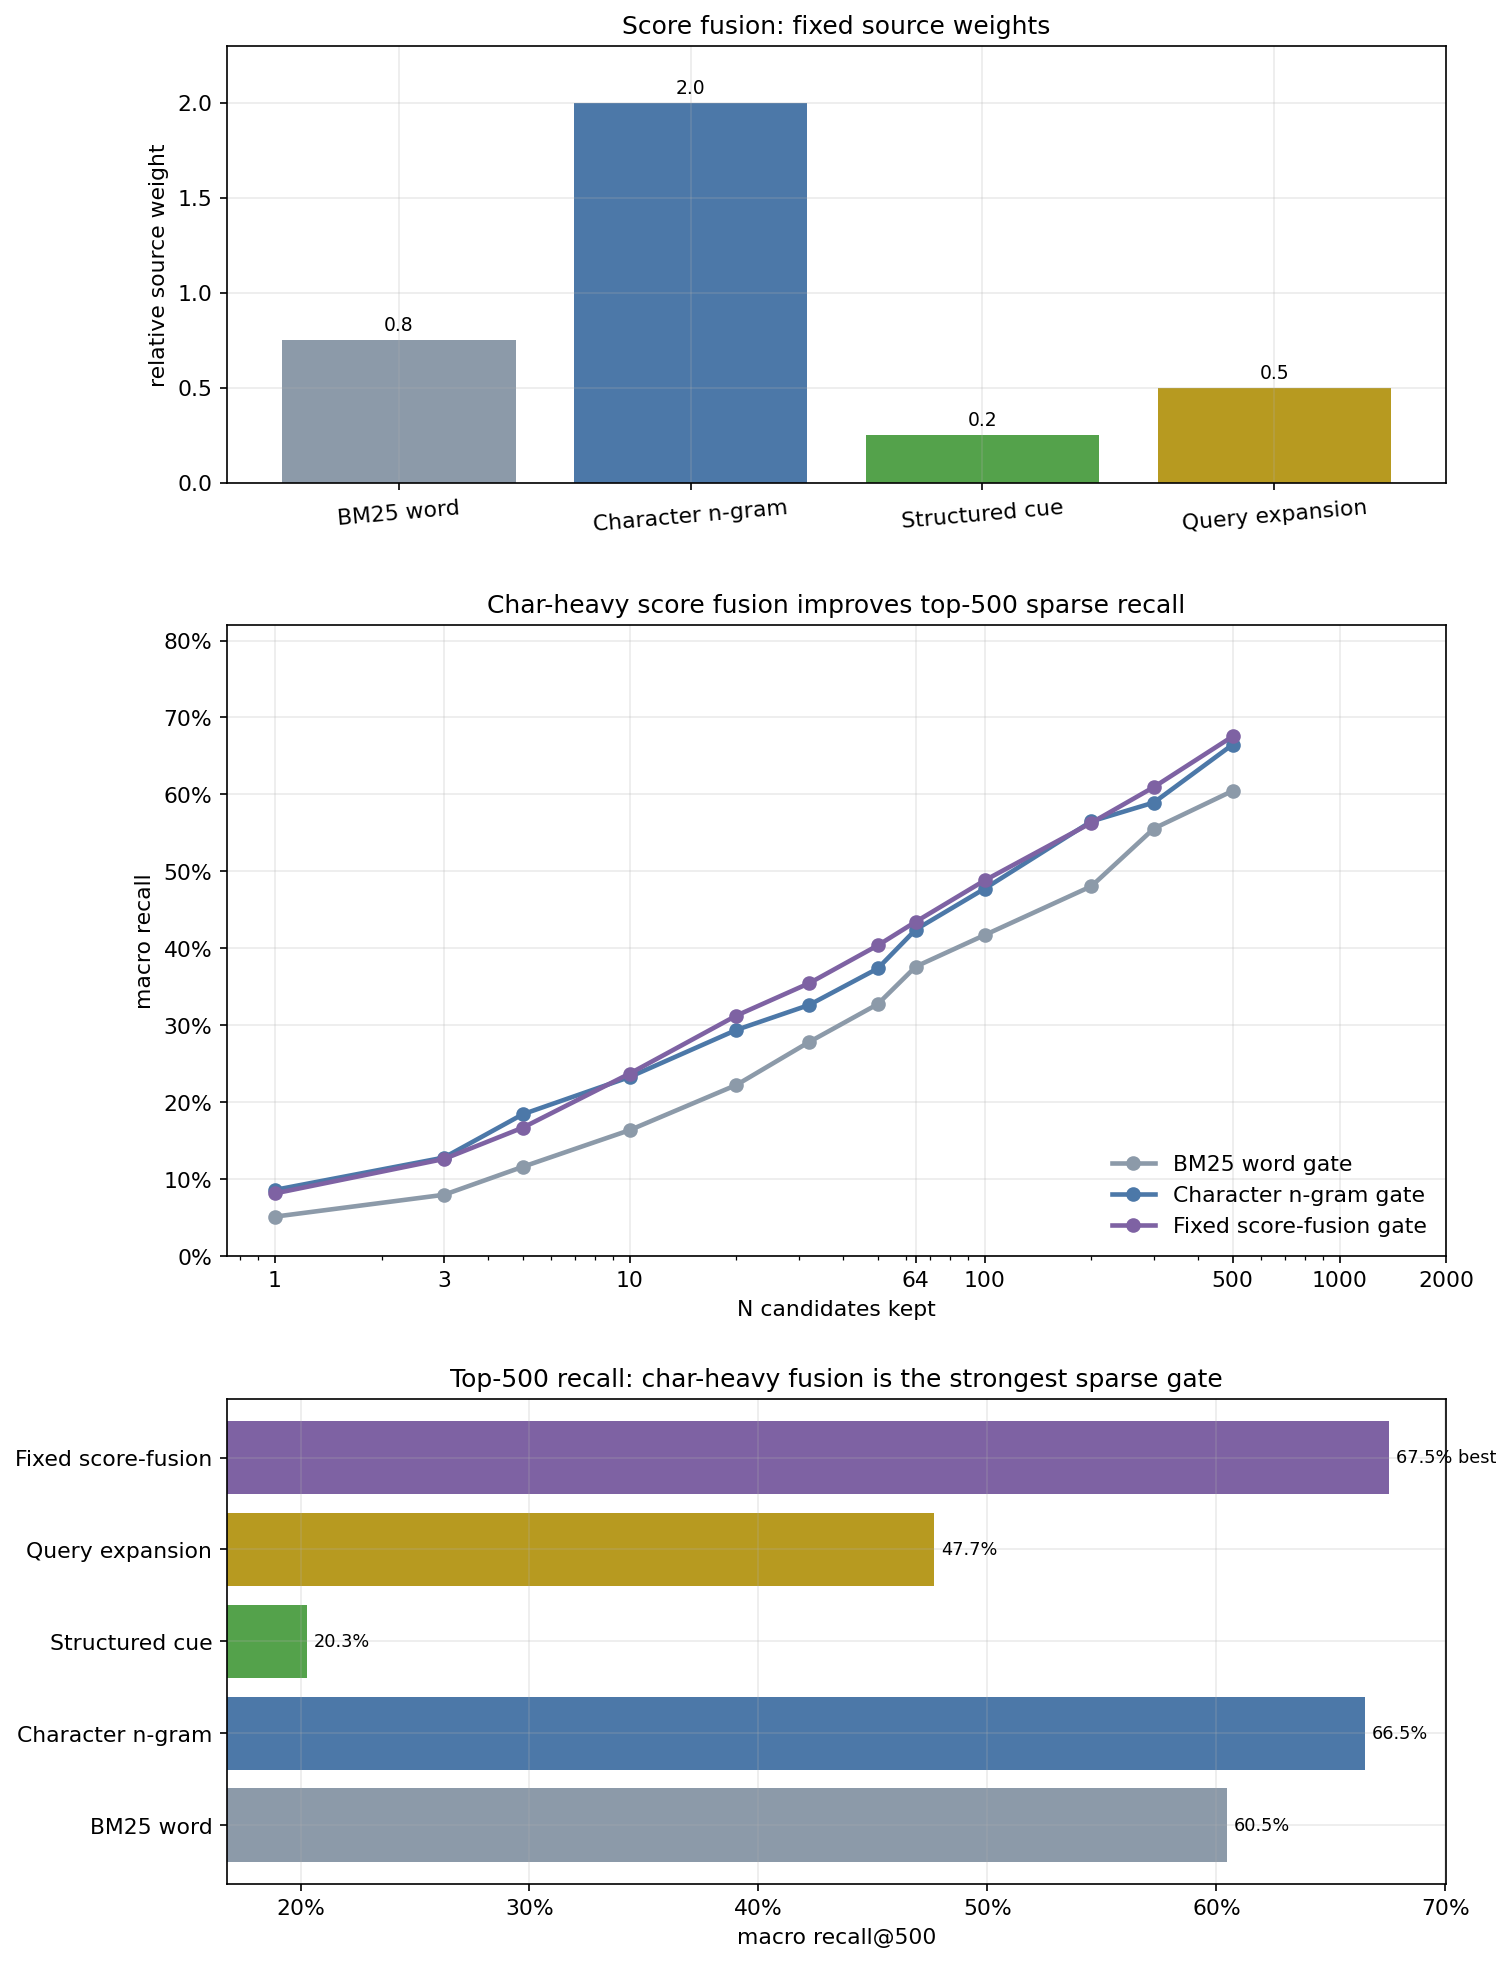

In [5]:
SPARSE_SOURCE_WEIGHTS = {
    'BM25 word gate': 0.75,
    'Character n-gram gate': 2.0,
    'Structured cue gate': 0.25,
    'Query expansion gate': 0.5,
}
fig, (ax0, ax1, ax2) = plt.subplots(
    3,
    1,
    figsize=(10.2, 13.2),
    gridspec_kw={'height_ratios': [0.9, 1.3, 1.0]},
)

weight_names = list(SPARSE_SOURCE_WEIGHTS)
weight_labels = ['BM25 word', 'Character n-gram', 'Structured cue', 'Query expansion']
ax0.bar(weight_labels, list(SPARSE_SOURCE_WEIGHTS.values()),
        color=[method_color(name) for name in SPARSE_SOURCE_WEIGHTS])
ax0.set_ylim(0, 2.3)
ax0.set_ylabel('relative source weight')
ax0.set_title('Score fusion: fixed source weights')
ax0.tick_params(axis='x', rotation=5)
for idx, value in enumerate(SPARSE_SOURCE_WEIGHTS.values()):
    ax0.text(idx, value + 0.05, f'{value:.1f}', ha='center', fontsize=9)

for name in ['BM25 word gate', 'Character n-gram gate', 'Fixed score-fusion gate']:
    curve = curves[name]
    ax1.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.2, label=name, color=method_color(name))
style_rn_axis(ax1)
ax1.set_title('Char-heavy score fusion improves top-500 sparse recall')
ax1.legend(loc='lower right')

top500_names = [
    'BM25 word gate',
    'Character n-gram gate',
    'Structured cue gate',
    'Query expansion gate',
    'Fixed score-fusion gate',
]
top500_vals = [value_at(curves[name], 500) for name in top500_names]
y = np.arange(len(top500_names))
ax2.barh(
    [name.replace(' gate', '') for name in top500_names],
    top500_vals,
    color=[method_color(name) for name in top500_names],
)
ax2.xaxis.set_major_formatter(PERCENT)
ax2.set_xlim(max(0.0, min(top500_vals) - 0.035), min(1.0, max(top500_vals) + 0.025))
ax2.set_xlabel('macro recall@500')
ax2.set_title('Top-500 recall: char-heavy fusion is the strongest sparse gate')
best_idx = int(np.argmax(top500_vals))
for idx, value in enumerate(top500_vals):
    label = f'{value:.1%}'
    if idx == best_idx:
        label += ' best'
    ax2.text(value + 0.003, idx, label, va='center', fontsize=8.5)
fig.tight_layout(h_pad=2.2)
savefig('round18_revised_sparse_fusion_weights_and_rn.png')
plt.show()


## 4.2 Candidate-Union Fusion

Candidate union is the second way to combine gates. Instead of giving each source a weight and producing one score, we first take the top candidates from several sources, deduplicate them, and keep a larger pool ordered by a simple source-rank rule. The last variant adds a cheap hand-feature ranker to compress that larger union back to a final top-500.

This section is diagnostic rather than the final decision: it shows why union can help coverage, and why the union pool becomes a cost question once it needs an extra ranker.


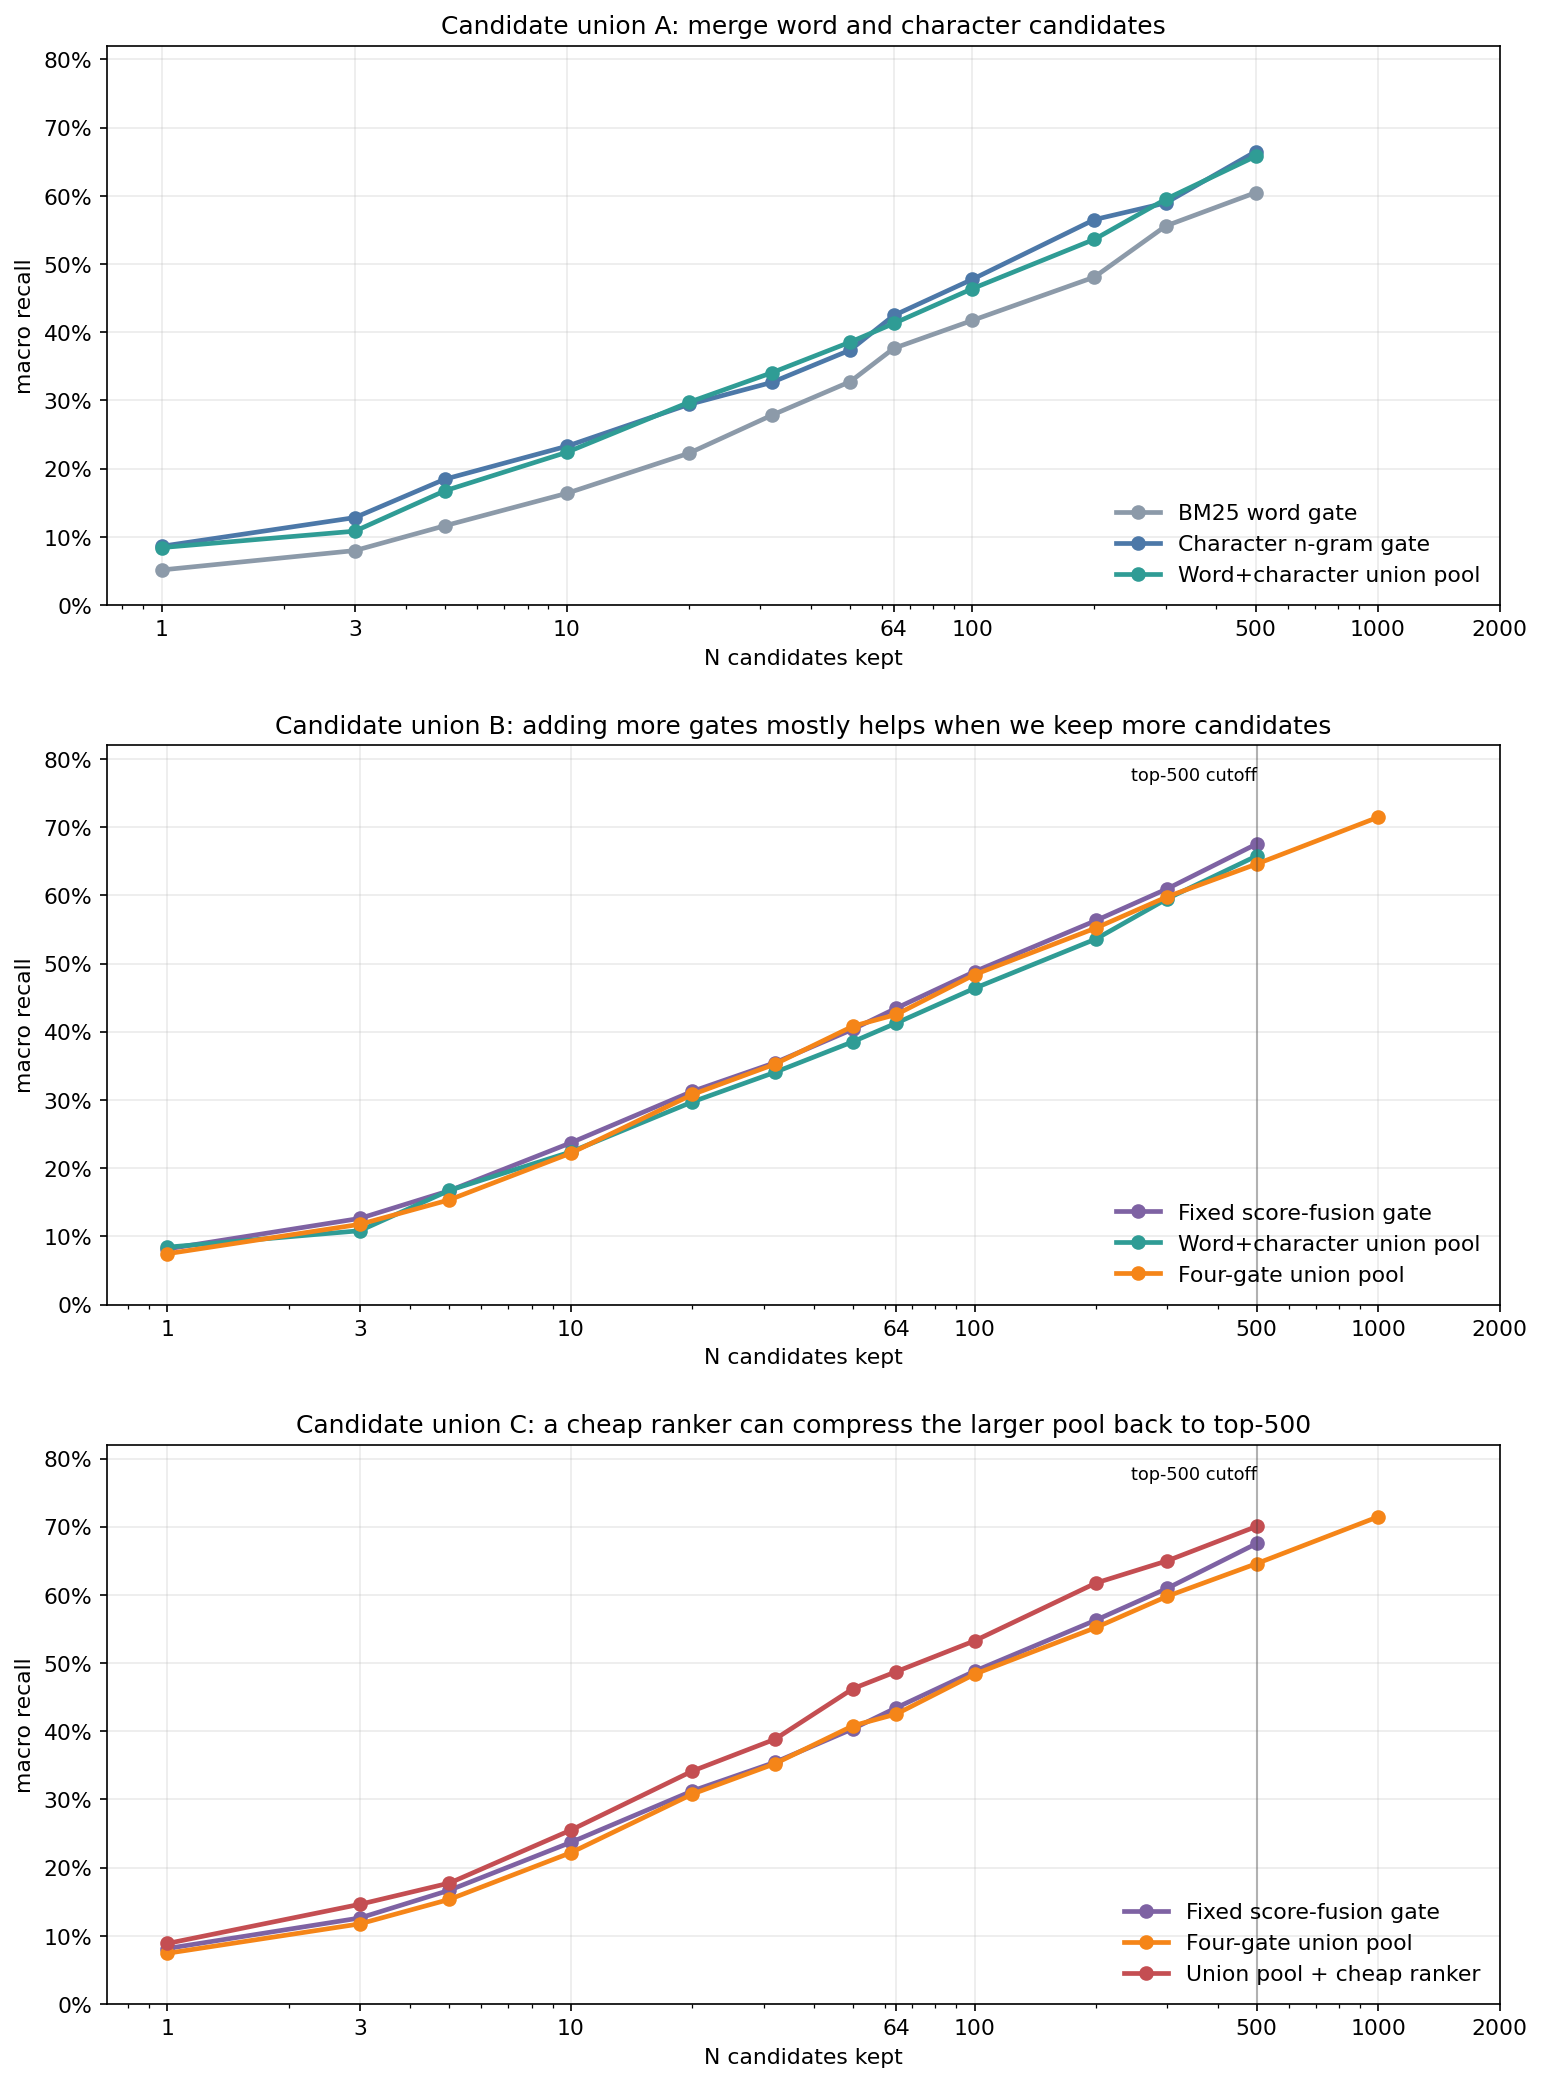

In [6]:
fig, (ax0, ax1, ax2) = plt.subplots(
    3,
    1,
    figsize=(10.4, 14.0),
    gridspec_kw={'height_ratios': [1.0, 1.0, 1.0]},
)

for name in ['BM25 word gate', 'Character n-gram gate', 'Word+character union pool']:
    curve = curves[name]
    ax0.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax0)
ax0.set_title('Candidate union A: merge word and character candidates')
ax0.legend(loc='lower right')

for name in ['Fixed score-fusion gate', 'Word+character union pool', 'Four-gate union pool']:
    curve = curves[name]
    ax1.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax1)
ax1.set_title('Candidate union B: adding more gates mostly helps when we keep more candidates')
ax1.legend(loc='lower right')
ax1.axvline(500, color='#333333', lw=1.0, alpha=0.32)
ax1.text(500, 0.79, 'top-500 cutoff', va='top', ha='right', fontsize=8.5)

for name in ['Fixed score-fusion gate', 'Four-gate union pool', 'Union pool + cheap ranker']:
    curve = curves[name]
    ax2.plot([x['top_n'] for x in curve], [x['macro_recall'] for x in curve], marker='o', lw=2.25, label=name, color=method_color(name))
style_rn_axis(ax2)
ax2.set_title('Candidate union C: a cheap ranker can compress the larger pool back to top-500')
ax2.legend(loc='lower right')
ax2.axvline(500, color='#333333', lw=1.0, alpha=0.32)
ax2.text(500, 0.79, 'top-500 cutoff', va='top', ha='right', fontsize=8.5)

fig.tight_layout(h_pad=2.1)
savefig('round18_revised_union_strategy_rn.png')
plt.show()


# 5. Why The Final Top-500 Uses Score Fusion

The union route proves that larger candidate pools can recover extra evidence, but the useful union result needs an additional cheap ranker. Once we include runtime, the top-500 choice is no longer just "which recall is highest"; it is "which recall gain is worth the extra cost." The final strict top-500 gate therefore uses fixed score fusion.


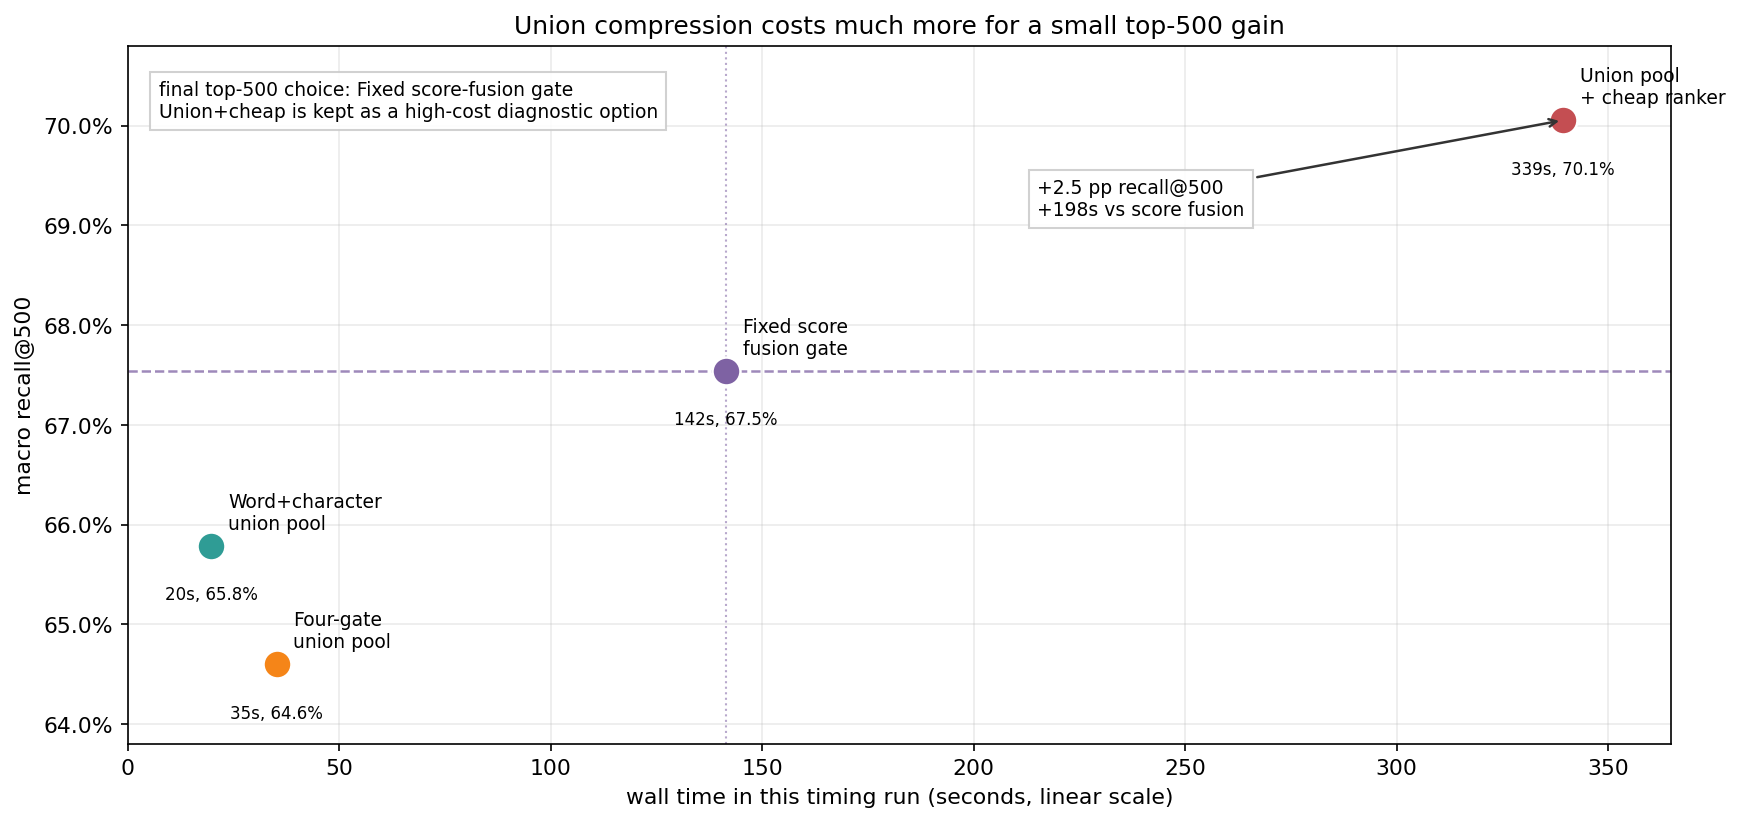

In [7]:
tradeoff_rows = [
    {
        'name': 'Fixed score-fusion gate',
        'seconds': manifest_seconds('round18/outputs/o_sparse/o_s7_plain_leaf_fusion/run_manifest.json'),
        'recall500': value_at(curves['Fixed score-fusion gate'], 500),
    },
    {
        'name': 'Word+character union pool',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s9_bm25_char_dev/run_manifest.json'),
        'recall500': value_at(curves['Word+character union pool'], 500),
    },
    {
        'name': 'Four-gate union pool',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s9_four_source_wide_dev/run_manifest.json'),
        'recall500': value_at(curves['Four-gate union pool'], 500),
    },
    {
        'name': 'Union pool + cheap ranker',
        'seconds': manifest_seconds('round18/outputs/timing/broad_pool/o_s10_bm25_char_round_robin_top1000/run_manifest.json'),
        'recall500': value_at(curves['Union pool + cheap ranker'], 500),
    },
]
baseline = tradeoff_rows[0]
display_names = ['Fixed score\nfusion gate', 'Word+character\nunion pool', 'Four-gate\nunion pool', 'Union pool\n+ cheap ranker']

fig, ax = plt.subplots(figsize=(11.8, 5.6))
for row, label in zip(tradeoff_rows, display_names):
    ax.scatter(
        row['seconds'],
        row['recall500'],
        s=180,
        color=method_color(row['name']),
        edgecolor='white',
        linewidth=1.2,
        zorder=3,
    )
    ax.annotate(
        label,
        (row['seconds'], row['recall500']),
        xytext=(8, 8),
        textcoords='offset points',
        fontsize=9,
    )
ax.axhline(baseline['recall500'], color=method_color('Fixed score-fusion gate'), ls='--', lw=1.2, alpha=0.75)
ax.axvline(baseline['seconds'], color=method_color('Fixed score-fusion gate'), ls=':', lw=1.0, alpha=0.55)
ax.set_xlim(0, 365)
ax.set_ylim(0.638, 0.708)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel('wall time in this timing run (seconds, linear scale)')
ax.set_ylabel('macro recall@500')
ax.set_title('Union compression costs much more for a small top-500 gain')
for row in tradeoff_rows:
    ax.text(
        row['seconds'],
        row['recall500'] - 0.004,
        f"{row['seconds']:.0f}s, {row['recall500']:.1%}",
        ha='center',
        va='top',
        fontsize=8,
    )
union_ranked = tradeoff_rows[-1]
ax.annotate(
    f"+{(union_ranked['recall500'] - baseline['recall500']) * 100:.1f} pp recall@500\n+{union_ranked['seconds'] - baseline['seconds']:.0f}s vs score fusion",
    xy=(union_ranked['seconds'], union_ranked['recall500']),
    xytext=(215, 0.691),
    arrowprops={'arrowstyle': '->', 'lw': 1.2, 'color': '#333333'},
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
ax.text(
    0.02,
    0.95,
    'final top-500 choice: Fixed score-fusion gate\nUnion+cheap is kept as a high-cost diagnostic option',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_union_cost_benefit.png')
plt.show()


# 6. Hand-Feature Design

Before comparing semantic rankers, we first isolate the manually engineered features. The feature families are shallow by design: exact overlap, source-rank signals, entity and number/year cues, length/shape, and simple logic indicators.

The first panel shows which feature families the learned ranker uses. The second panel shows the retrieval effect as an R-n curve, so the reader can see where the shallow selector improves candidate ordering.


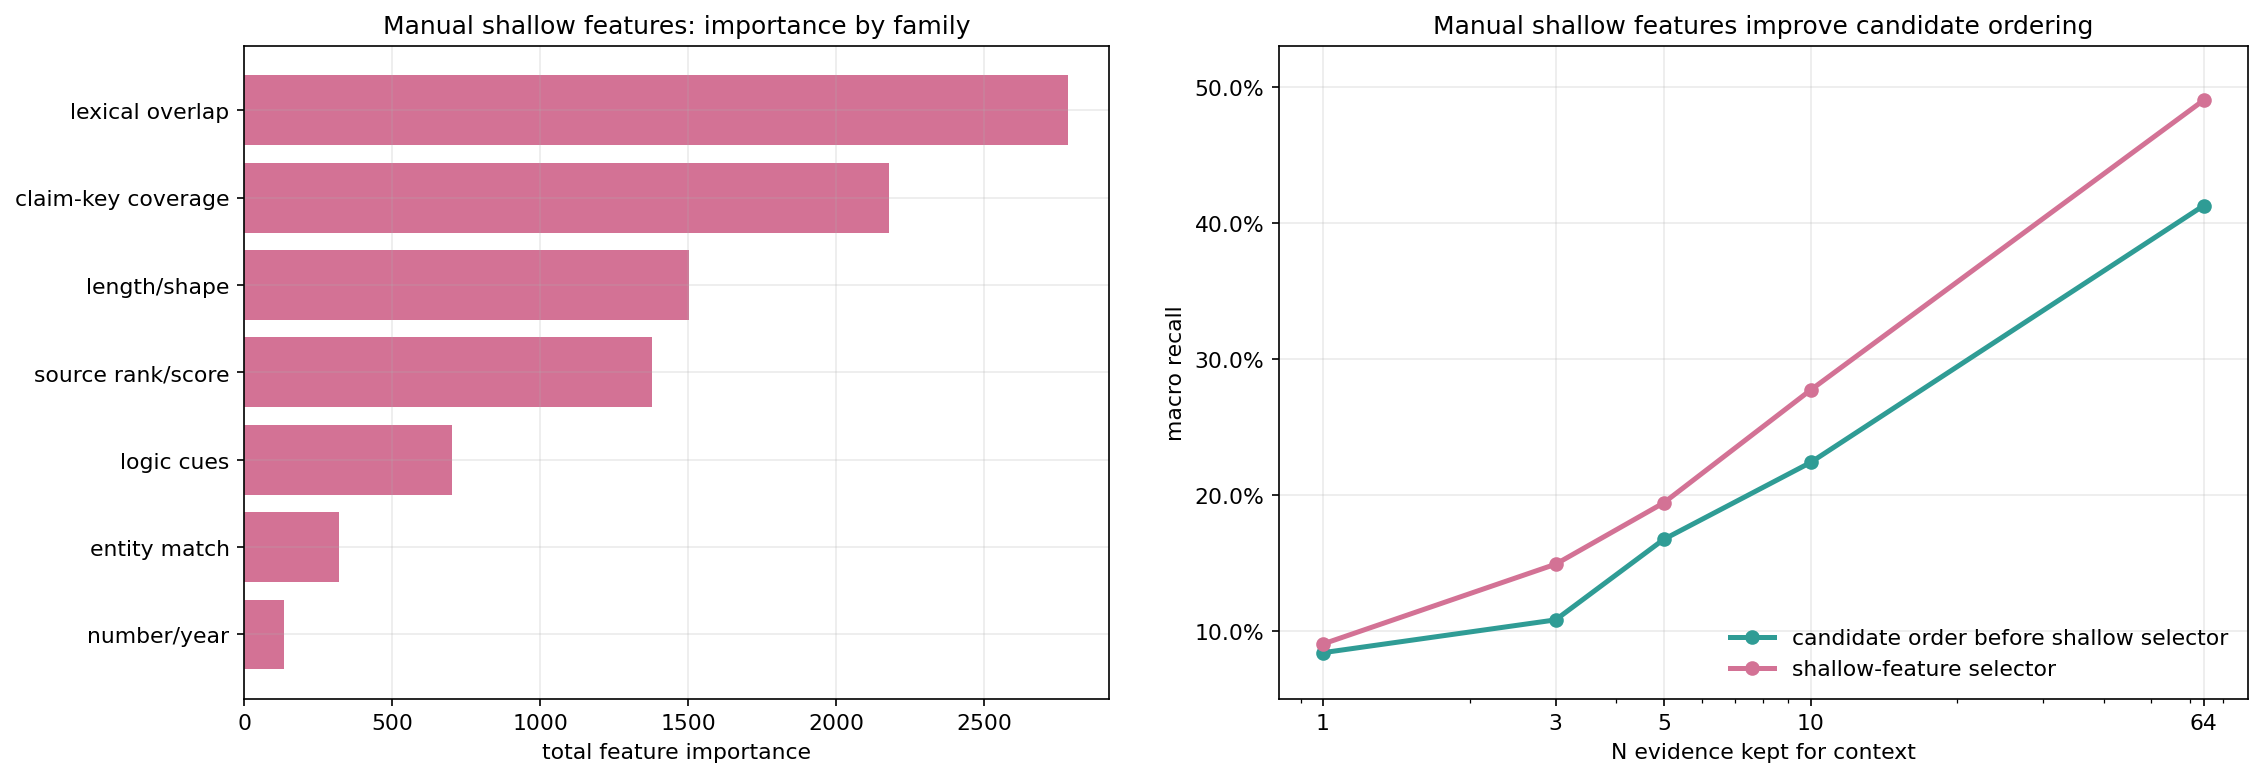

In [8]:
ce_shallow_summary = load_json('round18/reports/ce_shallow_feature_kfold/ce_shallow_feature_kfold_summary.json')
ce_shallow_rows = {row['variant']: row for row in ce_shallow_summary['rows']}
embedding_shallow_summary = load_json('round18/reports/embedding_shallow_feature_kfold/embedding_shallow_feature_kfold_summary.json')
embedding_shallow_rows = {row['variant']: row for row in embedding_shallow_summary['rows']}

def variant_curve(row, ks=(1, 3, 5, 10, 64)):
    return [
        {'top_n': k, 'macro_recall': row[f'dev_macro_recall@{k}']}
        for k in ks
        if f'dev_macro_recall@{k}' in row
    ]

hand_metrics = load_json('round18/outputs/o_sparse/o_s10_wide_hand_feature_bm25_char_rrf_top1000/dev_full_dev_o_s10_wide_hand_feature_bm25_char_rrf_top1000_metrics.json')
family_map = defaultdict(float)
for item in hand_metrics.get('feature_importance', []):
    feature = item['feature']
    if feature.startswith('claim_key'):
        family = 'claim-key coverage'
    elif feature.startswith('char') or feature.startswith('content') or 'gram' in feature:
        family = 'lexical overlap'
    elif 'rank' in feature or 'score' in feature:
        family = 'source rank/score'
    elif 'entity' in feature:
        family = 'entity match'
    elif 'number' in feature or 'year' in feature:
        family = 'number/year'
    elif 'length' in feature or feature.endswith('_len'):
        family = 'length/shape'
    else:
        family = 'logic cues'
    family_map[family] += float(item.get('importance', 0.0))
ordered_families = sorted(family_map.items(), key=lambda kv: kv[1], reverse=True)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15.2, 5.3), gridspec_kw={'width_ratios': [1.0, 1.12]})
ax0.barh(
    [name for name, _ in ordered_families][::-1],
    [value for _, value in ordered_families][::-1],
    color=method_color('Hand-feature reranker'),
)
ax0.set_xlabel('total feature importance')
ax0.set_title('Manual shallow features: importance by family')

shallow_curve = variant_curve(embedding_shallow_rows['shallow_only'])
direct_curve = [
    row for row in curves['Word+character candidate gate']
    if row['top_n'] in [1, 3, 5, 10, 64]
]
for curve, label, color in [
    (direct_curve, 'candidate order before shallow selector', method_color('Word+character candidate gate')),
    (shallow_curve, 'shallow-feature selector', method_color('Hand-feature reranker')),
]:
    ax1.plot(
        [x['top_n'] for x in curve],
        [x['macro_recall'] for x in curve],
        marker='o',
        lw=2.4,
        label=label,
        color=color,
    )
ax1.set_xscale('log')
ax1.set_xticks([1, 3, 5, 10, 64])
ax1.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}' if value >= 1 else ''))
ax1.yaxis.set_major_formatter(PERCENT)
percent_ylim(ax1, [x['macro_recall'] for x in direct_curve + shallow_curve], pad=0.04, floor=0.05, ceiling=0.60)
ax1.set_xlabel('N evidence kept for context')
ax1.set_ylabel('macro recall')
ax1.set_title('Manual shallow features improve candidate ordering')
ax1.legend(loc='lower right')
fig.tight_layout(w_pad=2.6)
savefig('round18_revised_hand_feature_design.png')
plt.show()


# 7. Top-64 Context Selection

Now we compare the three selector families that matter for classifier-context candidates: MiniLM cross-encoder, shallow feature selector, and MiniLM embedding inner product. All three operate over the same word+character top-500 candidate family.

This figure is a categorical comparison, so a bar chart is appropriate. The operating metric here is `recall@64`, because it measures whether the selector can bring gold evidence into the candidate context window. The classifier later chooses how much of that ranked context to consume; the final strict classifier uses k20.


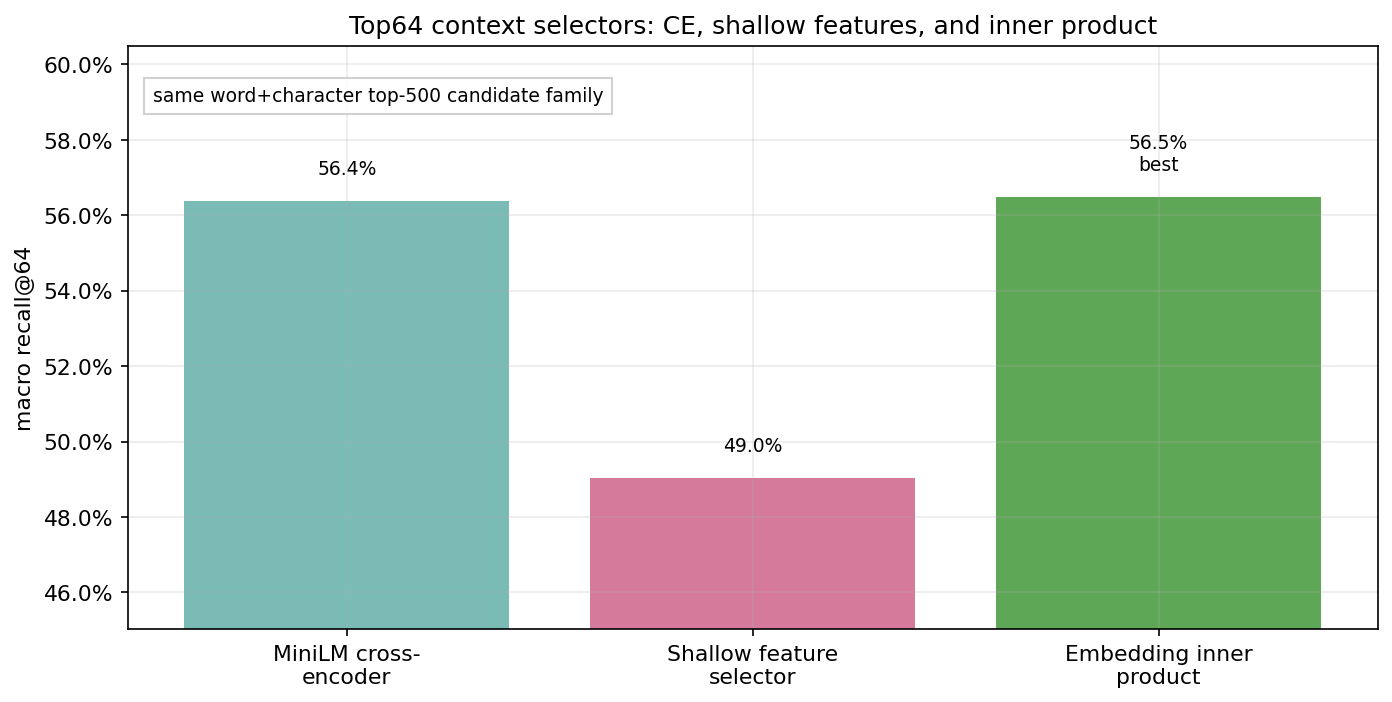

In [9]:
selector_rows = [
    {
        'label': 'MiniLM cross-\nencoder',
        'name': 'MiniLM cross-encoder selector',
        'value': metric_at(ce_shallow_rows['ce_only'], 64),
        'seconds': manifest_seconds('round18/outputs/o_dense/o_d3x_bm25_char_dev_top500/run_manifest.json'),
    },
    {
        'label': 'Shallow feature\nselector',
        'name': 'Hand-feature selector on same candidates',
        'value': metric_at(embedding_shallow_rows['shallow_only'], 64),
        'seconds': 0.0,
    },
    {
        'label': 'Embedding inner\nproduct',
        'name': 'Embedding inner-product selector',
        'value': metric_at(embedding_shallow_rows['embedding_only'], 64),
        'seconds': manifest_seconds('round18/outputs/o_dense/o_d1x_embedding_bm25_char_dev_top500/run_manifest.json'),
    },
]
vals = [row['value'] for row in selector_rows]
x = np.arange(len(selector_rows))
fig, ax = plt.subplots(figsize=(9.4, 4.8))
ax.bar(x, vals, color=[method_color(row['name']) for row in selector_rows], alpha=0.94)
for xpos, row in zip(x, selector_rows):
    value = row['value']
    label = f"{value:.1%}"
    if value == max(finite(vals)):
        label += "\nbest"
    ax.text(xpos, value + 0.006, label, ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([row['label'] for row in selector_rows])
ax.yaxis.set_major_formatter(PERCENT)
percent_ylim(ax, vals, pad=0.04, floor=0.35, ceiling=0.64)
ax.set_ylabel('macro recall@64')
ax.set_title('Top64 context selectors: CE, shallow features, and inner product')
ax.text(
    0.02,
    0.93,
    'same word+character top-500 candidate family',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_top64_selector_three_way_bar.png')
plt.show()


# 8. Shallow Features As A Complement

The previous chart compares standalone selectors. The next question is incremental: can the shallow features supplement a semantic model?

We show two R-n curves side by side: shallow features added to the cross-encoder, and shallow features added to the embedding inner-product selector. This separates the two claims instead of hiding them in one bar chart.


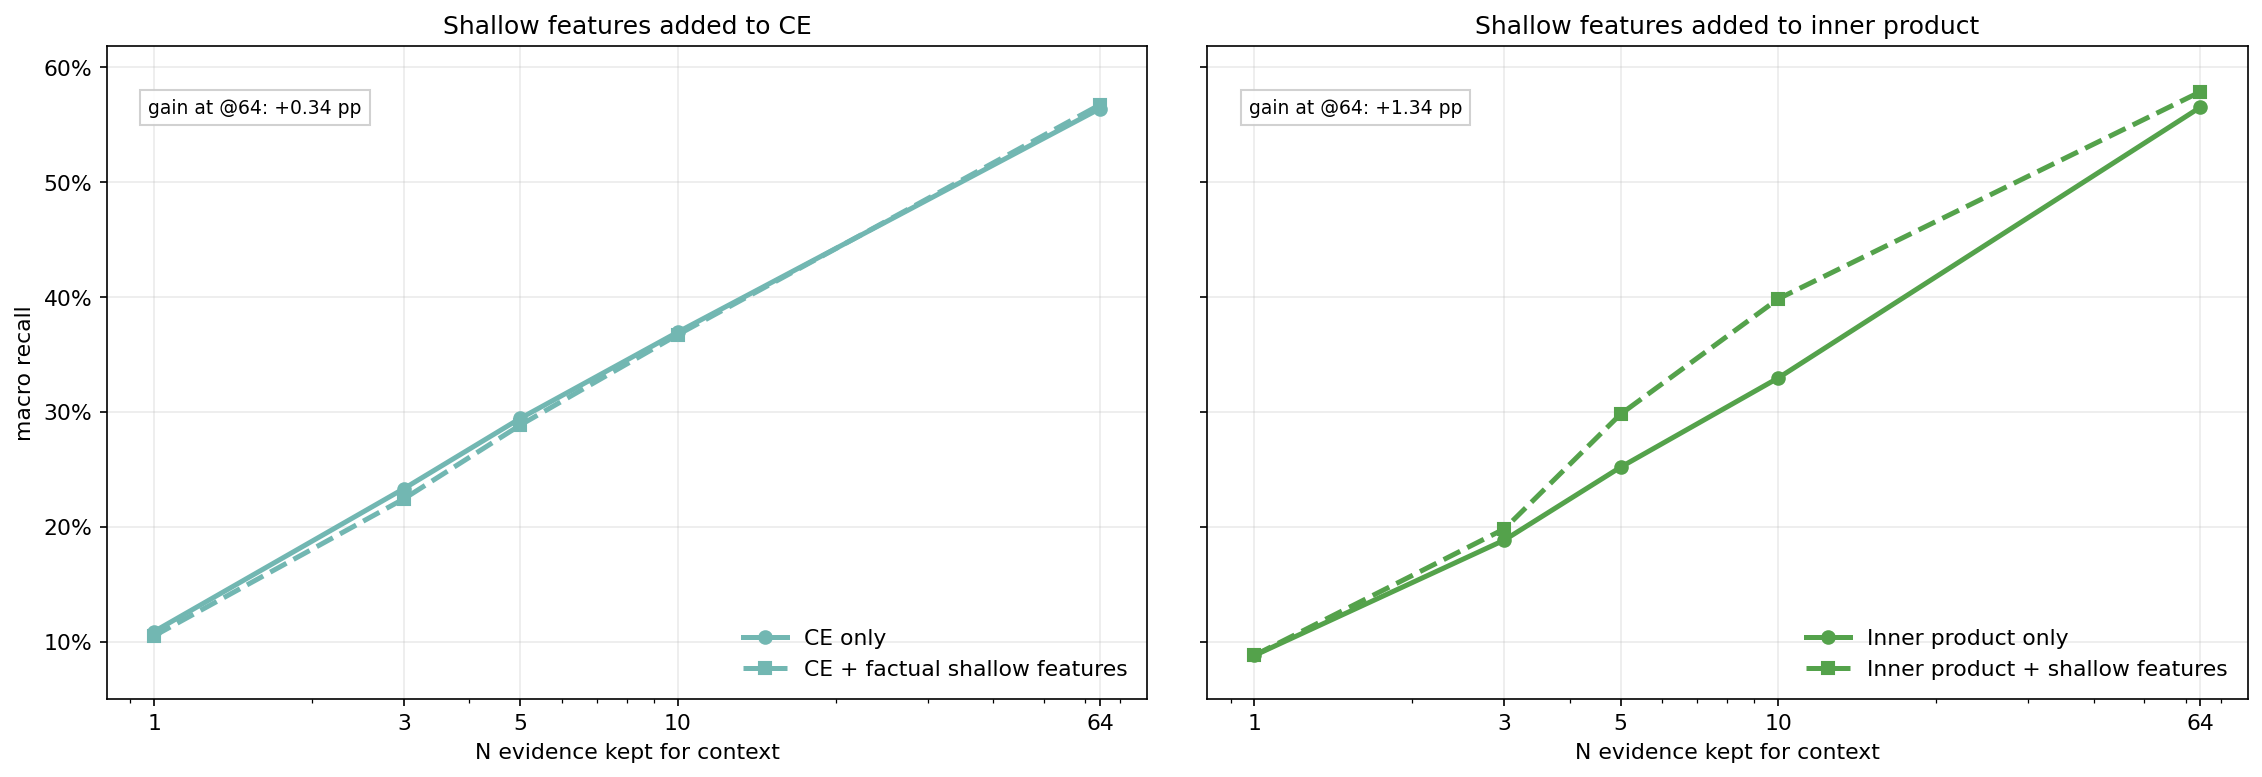

In [10]:
rn_ks = [1, 3, 5, 10, 64]
ce_selected_variant = ce_shallow_summary['best_variant']['variant']
embedding_selected_variant = embedding_shallow_summary['best_variant']['variant']

complement_panels = [
    {
        'title': 'Shallow features added to CE',
        'base_label': 'CE only',
        'base_row': ce_shallow_rows['ce_only'],
        'base_color': method_color('MiniLM cross-encoder selector'),
        'plus_label': 'CE + factual shallow features',
        'plus_row': ce_shallow_rows[ce_selected_variant],
    },
    {
        'title': 'Shallow features added to inner product',
        'base_label': 'Inner product only',
        'base_row': embedding_shallow_rows['embedding_only'],
        'base_color': method_color('Embedding inner-product selector'),
        'plus_label': 'Inner product + shallow features',
        'plus_row': embedding_shallow_rows[embedding_selected_variant],
    },
]

fig, axes = plt.subplots(1, 2, figsize=(15.2, 5.3), sharey=True)
all_values = []
for ax, panel in zip(axes, complement_panels):
    base_curve = variant_curve(panel['base_row'], rn_ks)
    plus_curve = variant_curve(panel['plus_row'], rn_ks)
    all_values.extend([x['macro_recall'] for x in base_curve + plus_curve])
    for curve, label, color, linestyle, marker in [
        (base_curve, panel['base_label'], panel['base_color'], '-', 'o'),
        (plus_curve, panel['plus_label'], panel['base_color'], '--', 's'),
    ]:
        ax.plot(
            [x['top_n'] for x in curve],
            [x['macro_recall'] for x in curve],
            marker=marker,
            lw=2.4,
            ls=linestyle,
            label=label,
            color=color,
        )
    base64 = panel['base_row']['dev_macro_recall@64']
    plus64 = panel['plus_row']['dev_macro_recall@64']
    ax.text(
        0.04,
        0.92,
        f"gain at @64: {(plus64 - base64) * 100:+.2f} pp",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
    )
    ax.set_xscale('log')
    ax.set_xticks(rn_ks)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}' if value >= 1 else ''))
    ax.yaxis.set_major_formatter(PERCENT)
    ax.set_xlabel('N evidence kept for context')
    ax.set_title(panel['title'])
    ax.legend(loc='lower right')
axes[0].set_ylabel('macro recall')
percent_ylim(axes[0], all_values, pad=0.04, floor=0.05, ceiling=0.64)
fig.tight_layout(w_pad=2.4)
savefig('round18_revised_shallow_complement_two_panel_rn.png')
plt.show()


# 9. Top-3 Evidence For Submission

The submitted evidence list is a different operating point from classifier context. The top-64 analysis evaluates context coverage, while the classifier later consumes a smaller ranked context. Top-3 is the final evidence ranking submitted with each claim.

We first inspect the three individual gates with a C-N curve, where C@N is claim coverage: the fraction of claims that have at least one gold evidence item in the first N positions. Then we fuse the gate signals and evaluate the final R-N curve, where R@N is macro evidence recall.

The final fusion weights are selected by train-claim k-folds, and dev is used only for confirmation. The old dev-selected blend is not promoted.


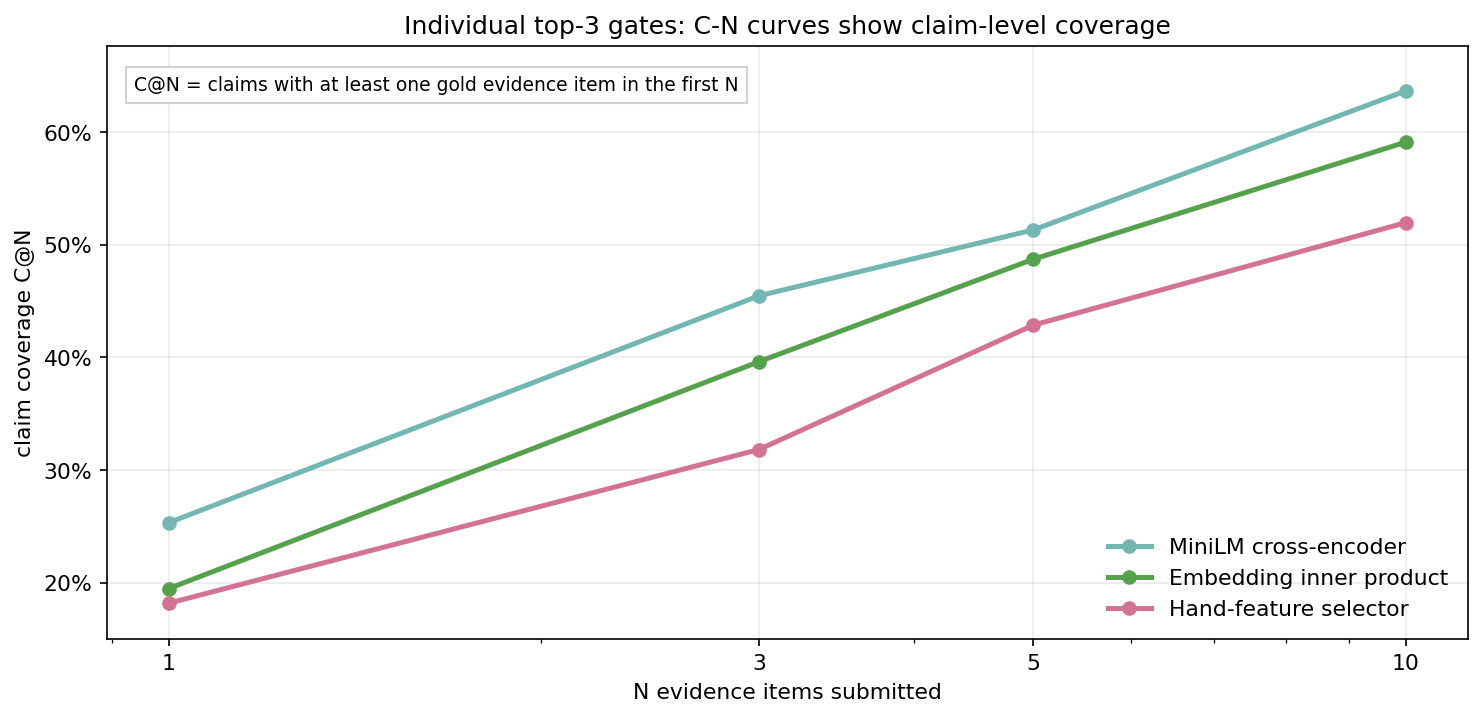

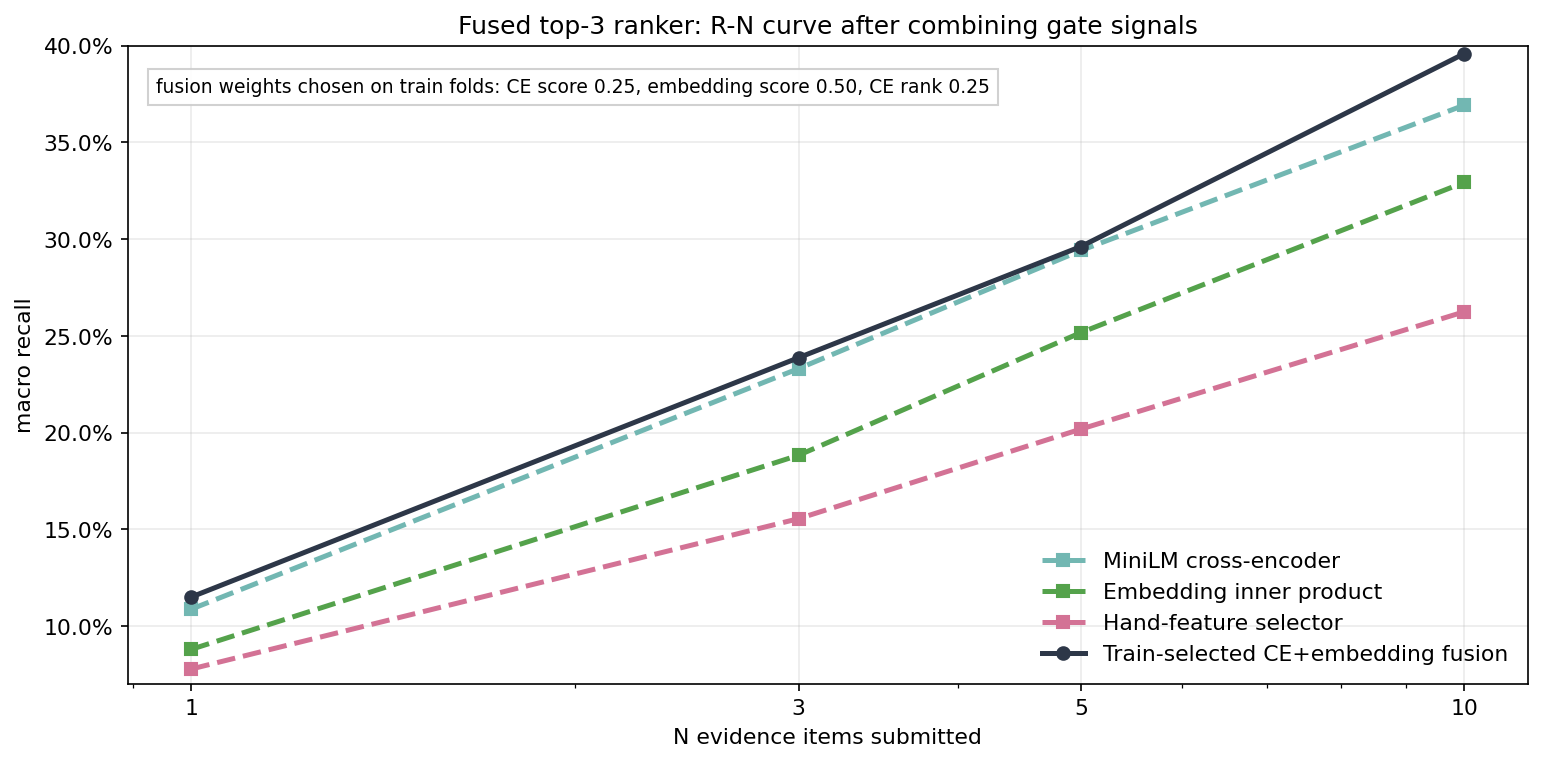

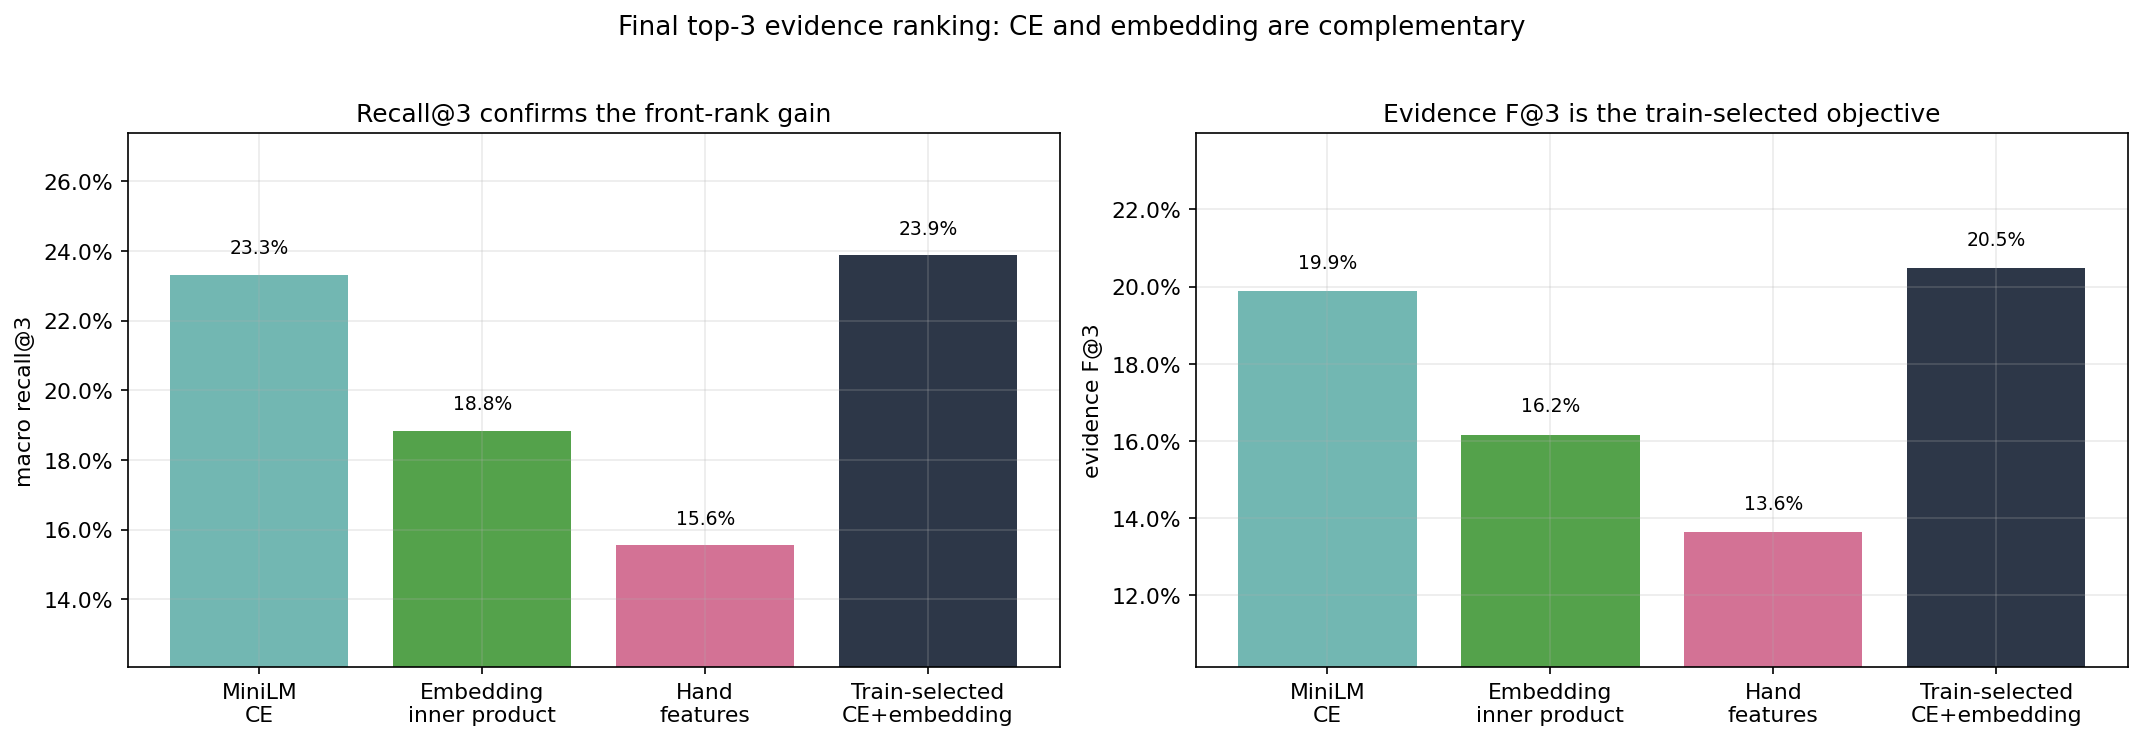

In [11]:
top3_gate_methods = [
    ('MiniLM cross-encoder', 'MiniLM cross-encoder selector'),
    ('Embedding inner product', 'Embedding inner-product selector'),
    ('Hand-feature selector', 'Hand-feature reranker'),
]
top3_methods = [
    *top3_gate_methods,
    ('Train-selected CE+embedding fusion', 'Train-selected CE+embedding top-3 fusion'),
]

fig, ax = plt.subplots(figsize=(10.0, 4.9))
for display, name in top3_gate_methods:
    if name not in curves:
        continue
    curve = [row for row in curves[name] if row['top_n'] <= 10]
    ax.plot(
        [x['top_n'] for x in curve],
        [x['hit_any'] for x in curve],
        marker='o',
        lw=2.4,
        label=display,
        color=method_color(name),
    )
ax.set_xscale('log')
ax.set_xticks([1, 3, 5, 10])
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}'))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_xlabel('N evidence items submitted')
ax.set_ylabel('claim coverage C@N')
ax.set_title('Individual top-3 gates: C-N curves show claim-level coverage')
ax.legend(loc='lower right')
ax.text(
    0.02,
    0.95,
    'C@N = claims with at least one gold evidence item in the first N',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
gate_cn_vals = [
    x['hit_any']
    for _, name in top3_gate_methods
    if name in curves
    for x in curves[name]
    if x['top_n'] <= 10
]
percent_ylim(ax, gate_cn_vals, pad=0.04, floor=0.15, ceiling=0.75)
fig.tight_layout()
savefig('round18_revised_top3_gate_cn.png')
plt.show()

fig, ax = plt.subplots(figsize=(10.4, 5.2))
for display, name in top3_methods:
    if name not in curves:
        continue
    curve = [row for row in curves[name] if row['top_n'] <= 10]
    linestyle = '-' if name == 'Train-selected CE+embedding top-3 fusion' else '--'
    marker = 'o' if name == 'Train-selected CE+embedding top-3 fusion' else 's'
    ax.plot(
        [x['top_n'] for x in curve],
        [x['macro_recall'] for x in curve],
        marker=marker,
        lw=2.4,
        ls=linestyle,
        label=display,
        color=method_color(name),
    )
ax.set_xscale('log')
ax.set_xticks([1, 3, 5, 10])
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}'))
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylim(0.07, 0.40)
ax.set_xlabel('N evidence items submitted')
ax.set_ylabel('macro recall')
ax.set_title('Fused top-3 ranker: R-N curve after combining gate signals')
ax.legend(loc='lower right')
ax.text(
    0.02,
    0.95,
    'fusion weights chosen on train folds: CE score 0.25, embedding score 0.50, CE rank 0.25',
    transform=ax.transAxes,
    ha='left',
    va='top',
    fontsize=9,
    bbox={'facecolor': 'white', 'edgecolor': '#cccccc', 'alpha': 0.9, 'pad': 4},
)
fig.tight_layout()
savefig('round18_revised_top3_submission_rn.png')
plt.show()

bar_methods = [
    ('MiniLM\nCE', 'MiniLM cross-encoder selector'),
    ('Embedding\ninner product', 'Embedding inner-product selector'),
    ('Hand\nfeatures', 'Hand-feature reranker'),
    ('Train-selected\nCE+embedding', 'Train-selected CE+embedding top-3 fusion'),
]
recall_vals = [value_at(curves[name], 3, 'macro_recall') for _, name in bar_methods]
f_vals = [value_at(curves[name], 3, 'evidence_f') for _, name in bar_methods]
x = np.arange(len(bar_methods))
fig, axes = plt.subplots(1, 2, figsize=(14.4, 4.8), sharex=True)
for ax, vals, title, ylabel in [
    (axes[0], recall_vals, 'Recall@3 confirms the front-rank gain', 'macro recall@3'),
    (axes[1], f_vals, 'Evidence F@3 is the train-selected objective', 'evidence F@3'),
]:
    ax.bar(x, vals, color=[method_color(name) for _, name in bar_methods])
    for xpos, value in zip(x, vals):
        ax.text(xpos, value + 0.005, f'{value:.1%}', ha='center', va='bottom', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([label for label, _ in bar_methods])
    ax.yaxis.set_major_formatter(PERCENT)
    percent_ylim(ax, vals, pad=0.035, floor=0.08, ceiling=0.30)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
fig.suptitle('Final top-3 evidence ranking: CE and embedding are complementary', y=1.02)
fig.tight_layout()
savefig('round18_revised_top3_submission_bar.png')
plt.show()


# 10. Classifier Hyperparameter Search

The retrieval and evidence-ranking stages are now fixed. The classifier tutorial follows one strict route only: use the selected context evidence, tune the text classifier inside the training split, and evaluate the chosen configuration once on dev.

The classifier family is the **Evidence-Aware Logistic Classifier**:

| part | final search space |
| --- | --- |
| context source | MiniLM cross-encoder context with factual feature support |
| context depth for selection | `k=20` evidence snippets |
| text representation | TF-IDF word `1-2` grams |
| max TF-IDF features | `30000`, `60000` |
| logistic regularization | `C={0.25, 0.5, 1, 2, 4}` |
| model family | logistic regression |

The tuning objective is train-holdout macro-F1. Dev is not used to choose `C` or feature count. The selected Context20 model is `max_features=60000`, `C=4.0`. After this selection is fixed, the first classifier figure reports the overall dev score, per-class recall, and confusion matrix.


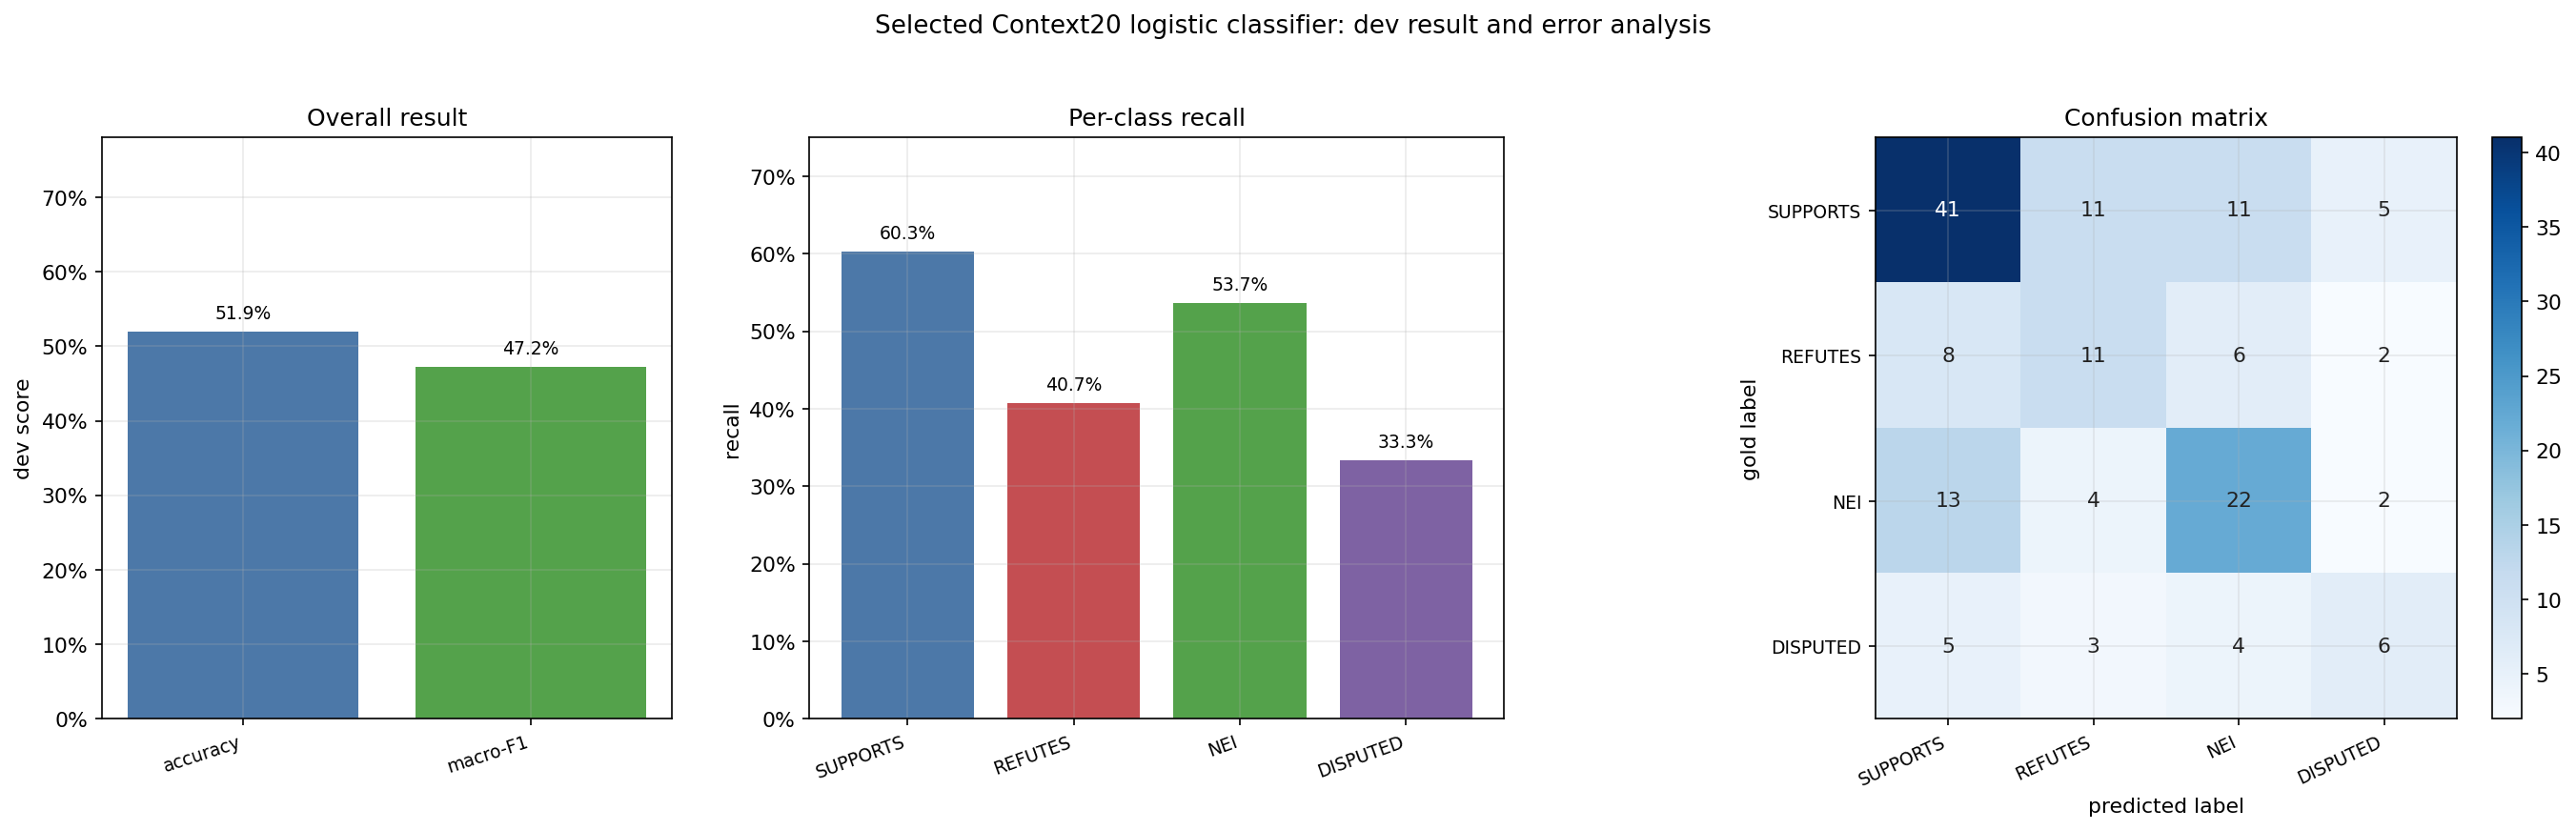

In [12]:
def numeric(row, key):
    value = row.get(key, '')
    return float(value) if value not in ('', None) else None

def load_confusion(path):
    rows = []
    with (ROOT / path).open('r', encoding='utf-8', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)[1:]
        for row in reader:
            rows.append([int(x) for x in row[1:]])
    return header, np.array(rows)

context20_grid = load_json('round18/outputs/o_classifier/o_c4_ce_factual_context_k20_trainholdout/o_c4_ce_factual_context_k20_trainholdout_tfidf_logreg_grid_search.json')
context20_metrics = load_json('round18/outputs/o_classifier/o_c4_ce_factual_context_k20_trainholdout/o_c4_ce_factual_context_k20_trainholdout_tfidf_logreg_mf60000_ngram1x2_c4p0_metrics.json')
conf_labels, conf = load_confusion('round18/outputs/o_classifier/o_c4_ce_factual_context_k20_trainholdout/o_c4_ce_factual_context_k20_trainholdout_tfidf_logreg_mf60000_ngram1x2_c4p0_confusion_matrix.csv')

per_class_recall = {}
for idx, label in enumerate(LABEL_ORDER):
    total = conf[idx].sum()
    per_class_recall[label] = conf[idx, conf_labels.index(label)] / total if total else 0.0

fig, (ax0, ax1, ax2) = plt.subplots(
    1,
    3,
    figsize=(18.2, 5.6),
    gridspec_kw={'width_ratios': [0.78, 0.95, 1.22]},
)

overall_metrics = [
    ('accuracy', context20_metrics['accuracy'], COLORS['blue']),
    ('macro-F1', context20_metrics['macro_f1'], COLORS['green']),
]
bars = ax0.bar(np.arange(len(overall_metrics)), [item[1] for item in overall_metrics], color=[item[2] for item in overall_metrics])
for bar, (_, value, _) in zip(bars, overall_metrics):
    ax0.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f'{value:.1%}', ha='center', va='bottom', fontsize=9)
ax0.set_xticks(np.arange(len(overall_metrics)))
ax0.set_xticklabels([item[0] for item in overall_metrics], rotation=18, ha='right', fontsize=9)
ax0.yaxis.set_major_formatter(PERCENT)
ax0.set_ylim(0.0, 0.78)
ax0.set_ylabel('dev score')
ax0.set_title('Overall result')

recall_vals = [per_class_recall[label] for label in LABEL_ORDER]
bars = ax1.bar(np.arange(len(LABEL_ORDER)), recall_vals, color=[LABEL_COLORS[label] for label in LABEL_ORDER])
for bar, value in zip(bars, recall_vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, value + 0.012, f'{value:.1%}', ha='center', va='bottom', fontsize=9)
ax1.set_xticks(np.arange(len(LABEL_ORDER)))
ax1.set_xticklabels([LABEL_DISPLAY[label] for label in LABEL_ORDER], rotation=20, ha='right', fontsize=9)
ax1.yaxis.set_major_formatter(PERCENT)
ax1.set_ylim(0, max(0.75, max(recall_vals) + 0.08))
ax1.set_ylabel('recall')
ax1.set_title('Per-class recall')

im = ax2.imshow(conf, cmap='Blues')
ax2.set_xticks(np.arange(len(conf_labels)))
ax2.set_yticks(np.arange(len(LABEL_ORDER)))
ax2.set_xticklabels([LABEL_DISPLAY.get(x, x) for x in conf_labels], rotation=25, ha='right', fontsize=9)
ax2.set_yticklabels([LABEL_DISPLAY[x] for x in LABEL_ORDER], fontsize=9)
ax2.set_xlabel('predicted label')
ax2.set_ylabel('gold label')
ax2.set_title('Confusion matrix')
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax2.text(j, i, str(conf[i, j]), ha='center', va='center', color='white' if conf[i, j] > conf.max() * 0.55 else '#222222')
fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

fig.suptitle('Selected Context20 logistic classifier: dev result and error analysis', y=1.03)
fig.tight_layout(w_pad=2.4)
savefig('round18_revised_context20_classifier_result.png')
plt.show()


# 11. Sensitivity Analysis

After the selected classifier result is fixed, the last section explains the two sensitivity checks. The C curve shows the train-holdout selection behavior within Context20. The context-depth curve changes the number of evidence snippets while keeping the same logistic classifier family and train-only selection rule.


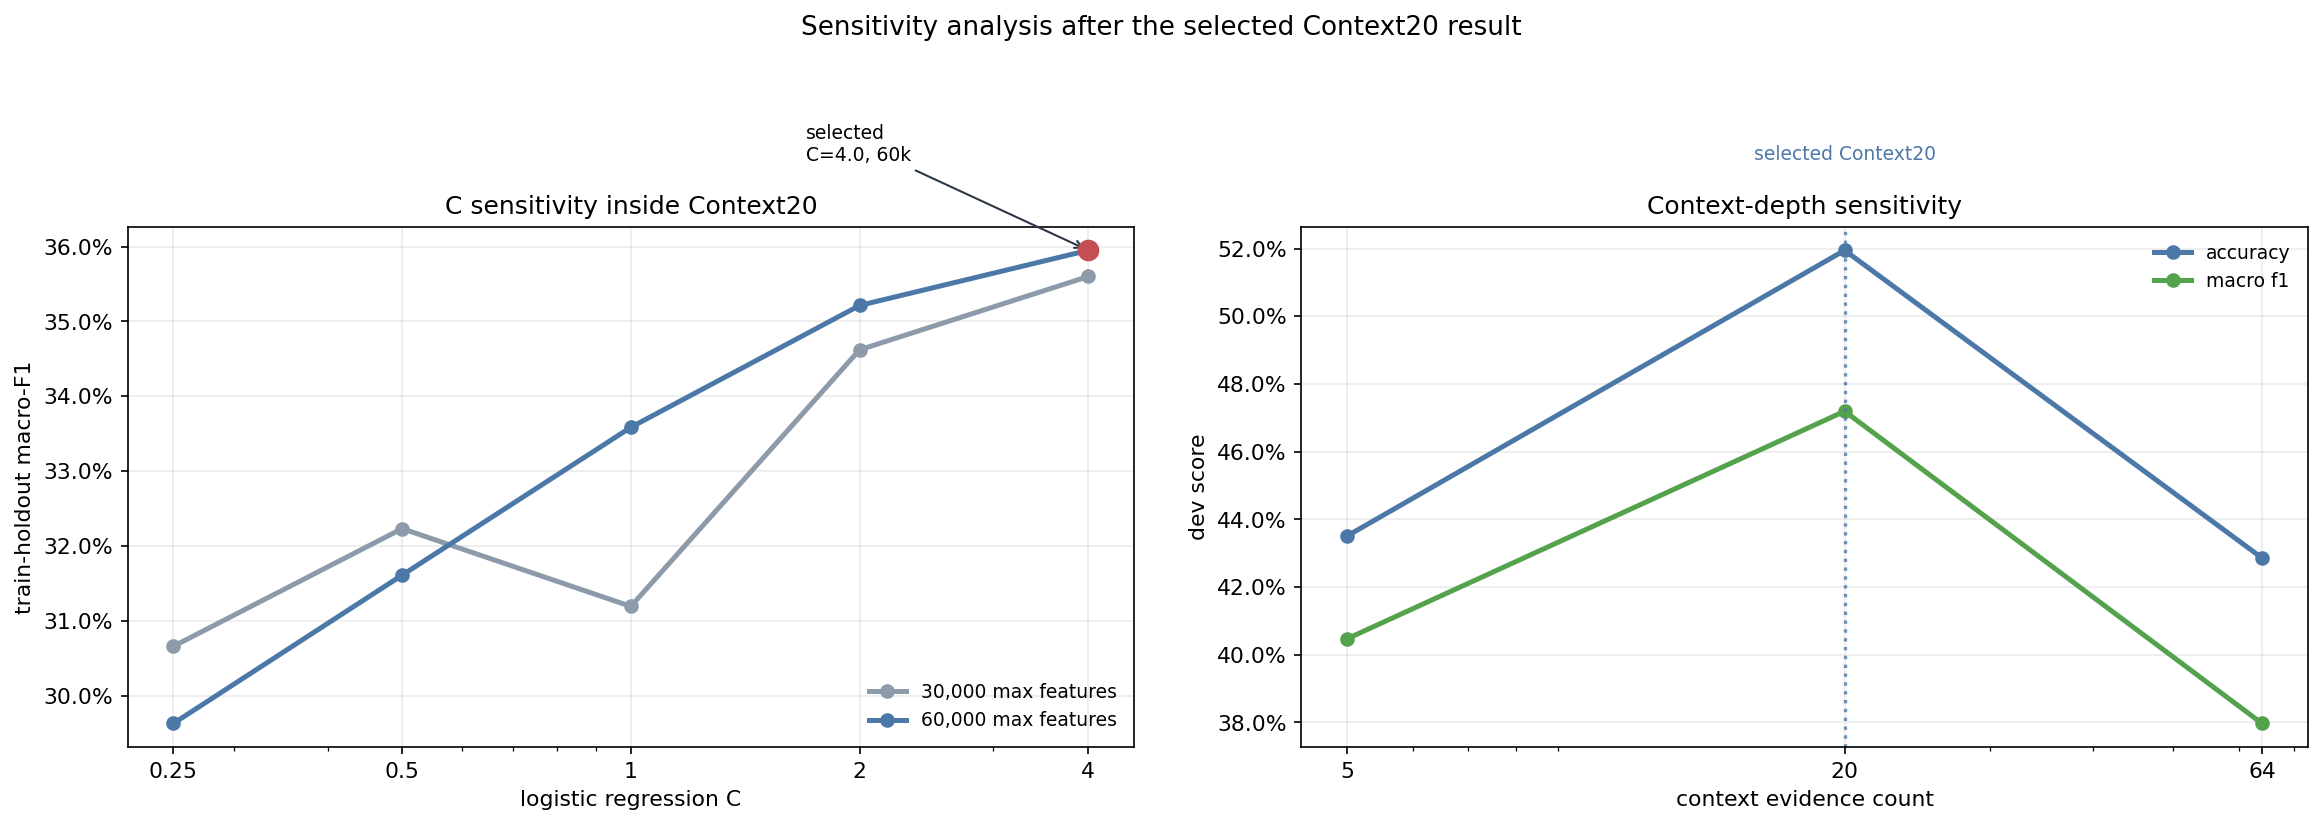

In [13]:
selection_rows = []
for row in context20_grid['best']['selection_meta'].get('selection_results', []):
    cfg = row['selection_config']
    selection_rows.append({
        'C': float(cfg['C']),
        'max_features': int(cfg['tfidf_max_features']),
        'macro_f1': row['macro_f1'],
        'accuracy': row['accuracy'],
    })
selection_rows.sort(key=lambda row: (row['max_features'], row['C']))
selected_cfg = context20_grid['best']['config']
selected_row = next(
    row for row in selection_rows
    if row['C'] == float(selected_cfg['C']) and row['max_features'] == int(selected_cfg['tfidf_max_features'])
)

classifier_metric_paths = {
    5: 'round18/outputs/o_classifier/o_c4_ce_factual_context_k5_trainholdout/o_c4_ce_factual_context_k5_trainholdout_tfidf_logreg_mf30000_ngram1x2_c0p5_metrics.json',
    20: 'round18/outputs/o_classifier/o_c4_ce_factual_context_k20_trainholdout/o_c4_ce_factual_context_k20_trainholdout_tfidf_logreg_mf60000_ngram1x2_c4p0_metrics.json',
    64: 'round18/outputs/o_classifier/o_c4_ce_factual_context_k64_trainholdout/o_c4_ce_factual_context_k64_trainholdout_tfidf_logreg_mf60000_ngram1x2_c2p0_metrics.json',
}
context_depth_rows = []
for k, path in classifier_metric_paths.items():
    m = load_json(path)
    context_depth_rows.append({
        'k': k,
        'accuracy': m['accuracy'],
        'macro_f1': m['macro_f1'],
    })
context_depth_rows.sort(key=lambda row: row['k'])

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15.6, 5.3), gridspec_kw={'width_ratios': [1.05, 1.05]})
for max_features, color in [(30000, COLORS['gray']), (60000, method_color('Evidence-Aware Logistic Classifier'))]:
    rows = [row for row in selection_rows if row['max_features'] == max_features]
    ax0.plot(
        [row['C'] for row in rows],
        [row['macro_f1'] for row in rows],
        marker='o',
        lw=2.4,
        color=color,
        label=f'{max_features:,} max features',
    )
ax0.scatter([selected_row['C']], [selected_row['macro_f1']], s=88, color=COLORS['red'], zorder=5)
ax0.annotate(
    'selected\nC=4.0, 60k',
    xy=(selected_row['C'], selected_row['macro_f1']),
    xytext=(1.7, selected_row['macro_f1'] + 0.012),
    arrowprops={'arrowstyle': '->', 'color': COLORS['black'], 'lw': 1.0},
    fontsize=9,
)
ax0.set_xscale('log')
ax0.set_xticks([0.25, 0.5, 1, 2, 4])
ax0.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{value:g}'))
ax0.yaxis.set_major_formatter(PERCENT)
ax0.set_xlabel('logistic regression C')
ax0.set_ylabel('train-holdout macro-F1')
ax0.set_title('C sensitivity inside Context20')
ax0.legend(loc='lower right', fontsize=9)

for key, color in [('accuracy', COLORS['blue']), ('macro_f1', COLORS['green'])]:
    ax1.plot([row['k'] for row in context_depth_rows], [row[key] for row in context_depth_rows], marker='o', lw=2.4, label=key.replace('_', ' '), color=color)
ax1.axvline(20, color=method_color('Evidence-Aware Logistic Classifier'), ls=':', lw=1.6, alpha=0.8)
ax1.text(20, 0.545, 'selected Context20', color=method_color('Evidence-Aware Logistic Classifier'), ha='center', va='bottom', fontsize=9)
ax1.set_xscale('log')
ax1.set_xticks([5, 20, 64])
ax1.xaxis.set_major_formatter(FuncFormatter(lambda value, _: f'{int(value)}'))
ax1.yaxis.set_major_formatter(PERCENT)
ax1.set_xlabel('context evidence count')
ax1.set_ylabel('dev score')
ax1.set_title('Context-depth sensitivity')
ax1.legend(loc='best', fontsize=9)

fig.suptitle('Sensitivity analysis after the selected Context20 result', y=1.03)
fig.tight_layout(w_pad=2.5)
savefig('round18_revised_classifier_sensitivity.png')
plt.show()
